In [1]:
import os
from experiments.CUP.common import run_cup_selection

SEEDS = [42]
TOP_K = 10

CONFIG_CUP = "experiments/CUP/configs/cup.yaml"
OUT_CUP = "experiments/CUP/results/cup"

os.makedirs(OUT_CUP, exist_ok=True)

# print("\n==============================")
# print("Running CUP model selection")
# print("==============================")

# out_cup = run_cup_selection(
#     config_path=CONFIG_CUP,
#     out_dir=OUT_CUP,
#     seeds=SEEDS,
#     top_k=TOP_K,
# )

# print("CUP DONE")
# print("Best score:", out_cup["best_score"])

In [1]:
import sys
import os

# Aggiunge la root al path
sys.path.append(os.getcwd())

# Importiamo il modulo common appena creato
from experiments.CUP import common

# --- CONFIGURAZIONE ---
CUP_ORIGINAL  = 'data/CUP/ML-CUP25-TR.csv' # Assicurati che il file sia qui
INT_TRAIN     = 'data/CUP/internal_train_90.csv'
INT_TEST      = 'data/CUP/internal_test_10.csv'
CONFIG_PATH   = 'experiments/CUP/configs/cup_coarse.yaml'
RESULTS_DIR   = 'experiments/CUP/results/cup_exp_1'

# --- 1. PREPARAZIONE DATI ---
# Crea lo split 80/20 salvando i file in formato compatibile con load_cup
common.create_internal_split(
    original_path=CUP_ORIGINAL, 
    train_save_path=INT_TRAIN, 
    test_save_path=INT_TEST,
    test_ratio=0.10
)

# # --- 2. GRID SEARCH & MODEL SELECTION ---
# # Esegue Coarse Search (Holdout) -> Selezione Top K -> Fine Search (K-Fold)
# # Tutto automatico come per il MONK
# print("\nAvvio Model Selection...")
# best_result = common.run_cup_selection(
#     config_path=CONFIG_PATH,
#     out_dir=RESULTS_DIR,
#     seeds=[42], # Puoi aggiungere altri seed se vuoi robustezza
#     top_k=10,
#     n_jobs = -1
# )

# print(f"\nExperiment completed. Results in: {RESULTS_DIR}")
# print(f"Best Configuration found: {best_result['best_config']}")

[CUP] Loading raw: data/CUP/ML-CUP25-TR.csv
[CUP] Saved split: data/CUP/internal_train_90.csv, data/CUP/internal_test_10.csv


### PROVA NUOVA

In [2]:
import json
import os
from training import model_factory
from training.trainer import Trainer
from data_handler.data_loader import load_cup

# --- 1. CARICAMENTO DELLA CONFIGURAZIONE MIGLIORE ---
# Percorso del file generato dallo step precedente
best_config_path = os.path.join(RESULTS_DIR, 'best_config.json')

with open(best_config_path, 'r') as f:
    config = json.load(f)

print("--- Configurazione Originale (Best) ---")
config
# print(json.dumps(config, indent=2)) # Decommenta per vedere tutto

--- Configurazione Originale (Best) ---


{'callbacks': {'early_stopping': True,
  'min_delta': '1e-5',
  'mode': 'min',
  'monitor': 'val_loss',
  'patience': 50,
  'restore_best_weights': True,
  'verbose': 0},
 'cv': {'k': 5, 'seed': 42, 'shuffle': True},
 'data': {'inputs': 12,
  'normalize': True,
  'normalize_target': True,
  'targets': 4,
  'train_path': 'data/CUP/internal_train_80.csv'},
 'model': {'activation': 'tanh',
  'dropout': 0.0,
  'hidden_units': [64, 32, 16],
  'output_activation': 'linear'},
 'optim': {'lr': 0.06, 'momentum': 0.8, 'name': 'sgd'},
 'regularizer': {'l2': 0.0008},
 'seed': 42,
 'split': {'stratified': False, 'val_size': 0.2},
 'training': {'batch_size': 64,
  'epochs': 800,
  'include_reg_in_val': False,
  'loss': 'mee',
  'metric': 'mee',
  'shuffle': True}}

In [3]:
# --- 2. MODIFICA MANUALE DEI PARAMETRI ---
# Qui puoi sovrascrivere qualsiasi parametro della grid search.
# Esempio: Vogliamo aumentare le epoche o cambiare il learning rate per un fine-tuning manuale.

# Esempio modifiche Training
config['training']['epochs'] = 1000     # Aumentiamo le epoche
config['training']['batch_size'] = 360      # Forziamo un batch size specifico
# config['training']['early_stopping']['patience'] = 25 # Cambiamo la pazienza

# Esempio modifiche Ottimizzatore (es. abbassare il LR)
config['optim']['lr'] = 0.01
config['optim']['momentum'] = 0.8

# Esempio modifiche Regolarizzazione (L2)
config['regularizer']['l2'] = 1e-4

# Esempio modifiche Architettura (Opzionale: attenzione a non rompere le dimensioni)
# config['model']['layers'][0]['units'] = 50 

print("\n--- Configurazione Modificata ---")
print(f"Epochs: {config['training']['epochs']}")
print(f"LR: {config['optim']['lr']}")
print(f"Lambda: {config['regularizer']['l2']}")


--- Configurazione Modificata ---
Epochs: 1000
LR: 0.01
Lambda: 0.0001


In [4]:
from data_handler.data_loader import normalize

# --- 3. CARICAMENTO E NORMALIZZAZIONE DATI ---
X_train_raw, y_train_raw = load_cup(INT_TRAIN)
X_test_raw, y_test_raw = load_cup(INT_TEST)

# Normalizza gli Input (fondamentale)
X_train, mean_x, std_x = normalize(X_train_raw)
# Usa media e std del training set per normalizzare il test set
X_test, _, _ = normalize(X_test_raw, mean=mean_x, std=std_x) 

# Opzionale: Normalizza gli Output (consigliato per Regressione CUP)
y_train, mean_y, std_y = normalize(y_train_raw)
y_test, _, _ = normalize(y_test_raw, mean=mean_y, std=std_y)

in_dim = X_train.shape[1]
out_dim = y_train.shape[1]

In [5]:
# --- 4. COSTRUZIONE DEL MODELLO ---
# Usiamo la funzione corretta presente nel tuo model_factory.py
print("Costruzione modello in corso...")
model = model_factory.build_model_from_cfg(
    run_cfg=config,
    seed=42,                # O un seed a tua scelta
    in_dim=in_dim,
    out_dim=out_dim,
    task='regression'       # FONDAMENTALE per il CUP (attiva Identity + MSE)
)

print("Modello creato correttamente.")

Costruzione modello in corso...
Modello creato correttamente.


In [6]:
# --- 4. ISTANZIAZIONE TRAINER ---
# CORREZIONE: Passiamo solo il modello e il flag verbose
trainer = Trainer(model=model, verbose=True)
print("\nTrainer istanziato correttamente.")


Trainer istanziato correttamente.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from nn.callbacks import EarlyStopping
from training.kfold_cv import kfold_cross_validation
# Assicurati che load_cup sia importato
from data_handler.data_loader import load_cup 

# 1. Carichiamo i dati GREZZI (Internal Train 90%)
# Non usiamo normalize() qui, lo farà la kfold_cross_validation internamente
X_cv_raw, y_cv_raw = load_cup(INT_TRAIN) 

print(f"Dati caricati per CV: X={X_cv_raw.shape}, y={y_cv_raw.shape}")

# 2. Configurazione Early Stopping
# Sovrascriviamo o aggiungiamo EarlyStopping ai callback del modello
# Nota: Modifichiamo la lista dei callback nel modello che hai già istanziato
early_stopping = EarlyStopping(
    monitor='val_loss',           # Monitoriamo la loss di validazione
    patience=50,                  # Numero di epoche di attesa (puoi modificarlo)
    min_delta=1e-4,               # Miglioramento minimo
    mode='min',                   # Vogliamo minimizzare la loss
    restore_best_weights=True,    # Fondamentale: alla fine ripristina i pesi migliori
    verbose=0                     # Meno output durante il training
)

# Aggiorniamo i callback del modello
model.callbacks = [early_stopping]

print("Early Stopping configurato e associato al modello.")

Dati caricati per CV: X=(450, 12), y=(450, 4)
Early Stopping configurato e associato al modello.


In [8]:
# Parametri per la CV
K_FOLDS = 5
EPOCHS = config['training']['epochs'] # O un numero alto, tanto c'è Early Stopping
BATCH_SIZE = config['training']['batch_size']

print(f"Avvio {K_FOLDS}-Fold CV con normalizzazione interna...")

# Esecuzione
train_stats, val_stats, histories, fold_results = kfold_cross_validation(
    X=X_cv_raw,
    y=y_cv_raw,
    model=model,
    trainer=trainer,
    k=K_FOLDS,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    verbose=1,                 # Vedrai i progressi dei fold
    include_reg_in_val=True,   # Include la regolarizzazione nella val loss
    normalize_data=True,       # ATTIVA normalizzazione input per fold
    normalize_target=True      # ATTIVA normalizzazione target per fold
)

print("\nCross Validation completata.")

Avvio 5-Fold CV con normalizzazione interna...
Task: Regression/Multi-output detected (y shape: (450, 4)) -> Using Standard KFold

Starting 5-Fold Cross Validation
Fold 1/5

      _____     ___                 _ _ _ 
      \_   \   / __\__ ___   ____ _| | (_)
       / /\/  / /  / _` \ \ / / _` | | | |
    /\/ /_   / /__| (_| |\ V / (_| | | | |
    \____/   \____/\__,_| \_/ \__,_|_|_|_|
    
Epoch 1/1000 [>.............................] loss: 7.1833 MEE: 2.5268 val_loss: 4.5538 val_MEE: 2.0263Epoch 2/1000 [>.............................] loss: 4.6092 MEE: 2.0138 val_loss: 4.9969 val_MEE: 2.0996Epoch 3/1000 [>.............................] loss: 4.7026 MEE: 2.0257 val_loss: 3.8764 val_MEE: 1.8435Epoch 4/1000 [>.............................] loss: 3.6503 MEE: 1.7735 val_loss: 2.7688 val_MEE: 1.5623Epoch 5/1000 [>.............................] loss: 2.8091 MEE: 1.5488 val_loss: 2.7517 val_MEE: 1.5586Epoch 6/1000 [>.............................] loss: 2.9873 MEE: 1.5984 val_loss: 2.7426 val

In [9]:
best_epochs = []
best_val_losses = []

print("\n--- Analisi Migliori Epoche per Fold ---")

for i, history in enumerate(histories):
    # CORREZIONE: Usiamo .logs invece di .history
    val_loss_history = history.logs['val_loss'] 
    
    # Troviamo l'indice del valore minimo
    best_epoch_idx = np.argmin(val_loss_history)
    best_epoch = best_epoch_idx + 1
    min_val_loss = val_loss_history[best_epoch_idx]
    
    best_epochs.append(best_epoch)
    best_val_losses.append(min_val_loss)
    
    print(f"Fold {i+1}: Best Epoch = {best_epoch}, Val Loss = {min_val_loss:.6f}")

avg_best_epoch = int(np.mean(best_epochs))
avg_val_loss = np.mean(best_val_losses)

print("-" * 30)
print(f"Media Best Epoch: {avg_best_epoch}")
print(f"Media Best Val Loss: {avg_val_loss:.6f}")


--- Analisi Migliori Epoche per Fold ---
Fold 1: Best Epoch = 1000, Val Loss = 1.584971
Fold 2: Best Epoch = 13, Val Loss = 2.826760
Fold 3: Best Epoch = 1000, Val Loss = 1.726693
Fold 4: Best Epoch = 600, Val Loss = 2.026211
Fold 5: Best Epoch = 991, Val Loss = 1.750308
------------------------------
Media Best Epoch: 720
Media Best Val Loss: 1.982989


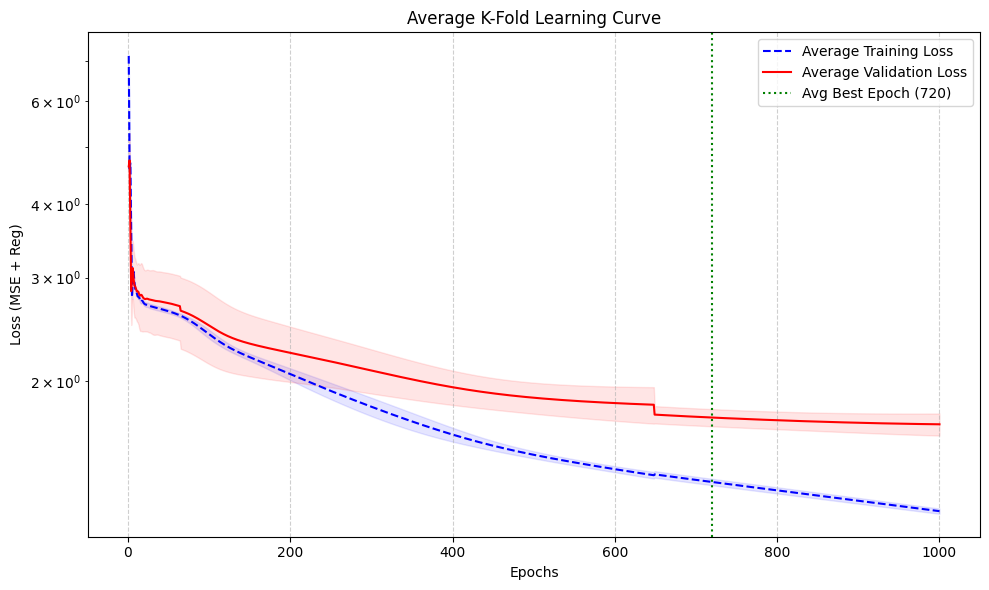

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Aggregazione dei Dati ---
# Determiniamo la lunghezza massima (numero di epoche) raggiunta
max_epochs = max([len(h.logs['loss']) for h in histories])

# Creiamo matrici piene di NaN: shape (n_folds, max_epochs)
all_train_loss = np.full((len(histories), max_epochs), np.nan)
all_val_loss = np.full((len(histories), max_epochs), np.nan)

# Riempiamo le matrici con i dati disponibili
for i, h in enumerate(histories):
    loss = h.logs['loss']
    val_loss = h.logs['val_loss']
    
    # Copiamo i valori fino alla lunghezza di questo fold
    all_train_loss[i, :len(loss)] = loss
    all_val_loss[i, :len(val_loss)] = val_loss

# --- 2. Calcolo Statistiche (Media e Std) ---
# Usiamo nanmean/nanstd per ignorare i valori mancanti (dove i fold erano già finiti)
mean_train_loss = np.nanmean(all_train_loss, axis=0)
std_train_loss = np.nanstd(all_train_loss, axis=0)

mean_val_loss = np.nanmean(all_val_loss, axis=0)
std_val_loss = np.nanstd(all_val_loss, axis=0)

# Calcolo epoca media di stop (per la linea verticale)
avg_best_epoch = int(np.mean(best_epochs))

# --- 3. Plotting ---
plt.figure(figsize=(10, 6))
epochs_range = range(1, max_epochs + 1)

# Plot Training
plt.plot(epochs_range, mean_train_loss, label='Average Training Loss', color='blue', linestyle='--')
plt.fill_between(epochs_range, 
                 mean_train_loss - std_train_loss, 
                 mean_train_loss + std_train_loss, 
                 color='blue', alpha=0.1)

# Plot Validation
plt.plot(epochs_range, mean_val_loss, label='Average Validation Loss', color='red')
plt.fill_between(epochs_range, 
                 mean_val_loss - std_val_loss, 
                 mean_val_loss + std_val_loss, 
                 color='red', alpha=0.1)

# Linea verticale per la "best epoch" media
plt.axvline(x=avg_best_epoch, color='green', linestyle=':', label=f'Avg Best Epoch ({avg_best_epoch})')

plt.title('Average K-Fold Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE + Reg)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.yscale('log') # Consigliato per vedere meglio la convergenza
plt.tight_layout()
plt.show()

In [11]:
import numpy as np
from sklearn.model_selection import KFold
from data_handler.data_loader import normalize, denormalize

# --- 1. CONFIGURAZIONE ---
k = 5
seed = 42
cv = KFold(n_splits=k, shuffle=True, random_state=seed)

fold_mee_scores = []

print(f"Inizio calcolo MEE su scala originale ({k}-Fold CV)...")

# --- 2. CICLO DI CROSS VALIDATION ---
# Usiamo X_cv_raw e y_cv_raw caricati precedentemente (dati non normalizzati)
for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_cv_raw, y_cv_raw)):
    
    # Split dei dati grezzi per questo fold
    X_train_raw, X_val_raw = X_cv_raw[train_idx], X_cv_raw[val_idx]
    y_train_raw, y_val_raw = y_cv_raw[train_idx], y_cv_raw[val_idx]

    # Normalizzazione (fondamentale per il training)
    # Calcoliamo le statistiche sul training fold e le applichiamo al validation fold
    X_train, mean_x, std_x = normalize(X_train_raw)
    X_val, _, _ = normalize(X_val_raw, mean=mean_x, std=std_x)
    
    y_train, mean_y, std_y = normalize(y_train_raw)
    # y_val_norm serve solo se volessimo calcolare la loss normalizzata
    y_val_norm, _, _ = normalize(y_val_raw, mean=mean_y, std=std_y)

    # Reset e Training del modello
    model.reset()
    trainer.fit(
        X_train=X_train, y_train=y_train,
        X_val=X_val, y_val=y_val_norm,
        epochs=config['training']['epochs'],
        batch_size=config['training']['batch_size']
        # verbose=0 # Silenzioso per non intasare il notebook
    )

    # --- 3. CALCOLO MEE IN SCALA ORIGINALE ---
    # Otteniamo le predizioni (ancora in scala normalizzata)
    y_pred_norm = model.predict_proba(X_val)
    
    # Riportiamo le predizioni alla scala originale del CUP
    y_pred_orig = denormalize(y_pred_norm, mean_y, std_y)
    
    # Calcolo dell'Errore Euclideo per ogni record: sqrt(sum((pred - target)^2))
    # Usiamo y_val_raw che è il target originale non toccato
    euclidean_distances = np.linalg.norm(y_pred_orig - y_val_raw, axis=1)
    
    # Media delle distanze per questo fold
    current_fold_mee = np.mean(euclidean_distances)
    fold_mee_scores.append(current_fold_mee)
    
    print(f"Fold {fold_idx + 1}: MEE (Original Scale) = {current_fold_mee:.4f}")

# --- 4. RISULTATI FINALI ---
mee_final_mean = np.mean(fold_mee_scores)
mee_final_std = np.std(fold_mee_scores)

print("\n" + "="*30)
print(f"VAL MEE FINALE MEDIO: {mee_final_mean:.4f} ± {mee_final_std:.4f}")
print("="*30)

Inizio calcolo MEE su scala originale (5-Fold CV)...
Epoch 1/1000 [>.............................] loss: 7.1833 MEE: 2.5268 val_loss: 4.5493 val_MEE: 2.0263Epoch 2/1000 [>.............................] loss: 4.6092 MEE: 2.0138 val_loss: 4.9924 val_MEE: 2.0996Epoch 3/1000 [>.............................] loss: 4.7026 MEE: 2.0257 val_loss: 3.8719 val_MEE: 1.8435Epoch 4/1000 [>.............................] loss: 3.6503 MEE: 1.7735 val_loss: 2.7644 val_MEE: 1.5623Epoch 5/1000 [>.............................] loss: 2.8091 MEE: 1.5488 val_loss: 2.7472 val_MEE: 1.5586Epoch 6/1000 [>.............................] loss: 2.9873 MEE: 1.5984 val_loss: 2.7381 val_MEE: 1.5538Epoch 7/1000 [>.............................] loss: 3.0743 MEE: 1.6262 val_loss: 2.6236 val_MEE: 1.5189Epoch 8/1000 [>.............................] loss: 2.9670 MEE: 1.6006 val_loss: 2.6272 val_MEE: 1.5222Epoch 9/1000 [>.............................] loss: 2.9007 MEE: 1.5878 val_loss: 2.7089 val_MEE: 1.5510Epoch 10/1000 [>....

In [13]:
import numpy as np
from data_handler.data_loader import normalize, denormalize

# --- 1. ADDESTRAMENTO FINALE (Se non già fatto) ---
# Prima di testare sul 10%, addestriamo il modello su TUTTO il 90% 
# usando la 'avg_best_epoch' trovata con la Cross Validation.

print(f"Addestramento finale su tutto l'internal train (90%) per {avg_best_epoch} epoche...")

# Usiamo i dati caricati e normalizzati all'inizio (X_train, y_train dal 90%)
model.reset()
trainer.fit(
    X_train=X_train, 
    y_train=y_train,
    epochs=avg_best_epoch, # Usiamo la media della Cross Validation
    batch_size=config['training']['batch_size'],
    # verbose=0
)

# --- 2. PREPARAZIONE DATI DI TEST (10%) ---
# X_test_raw e y_test_raw sono i dati mai visti dal modello.
# Fondamentale: usiamo mean/std del TRAINING per normalizzare il TEST.
X_test_norm, _, _ = normalize(X_test_raw, mean=mean_x, std=std_x)

# --- 3. PREDIZIONE E DENORMALIZZAZIONE ---
# Il modello produce output normalizzati
y_pred_norm = model.predict_proba(X_test_norm)

# Riportiamo le predizioni alla scala originale del CUP
# Usiamo mean_y e std_y calcolati sul set di training (90%)
y_pred_orig = denormalize(y_pred_norm, mean=mean_y, std=std_y)

# --- 4. CALCOLO MEE FINALE ---
# Calcolo della distanza euclidea per ogni record rispetto ai target reali (raw)
# Formula: sqrt(sum((y_pred - y_true)^2))
errors = np.linalg.norm(y_pred_orig - y_test_raw, axis=1)

# Media degli errori euclidei
final_mee_test = np.mean(errors)

print("\n" + "="*40)
print(f"RISULTATO FINALE SULL'INTERNAL TEST SET")
print(f"MEE (Original Scale): {final_mee_test:.4f}")
print("="*40)

# Opzionale: Visualizzazione di alcuni esempi
print("\nConfronto prime 5 predizioni (Originale vs Predetto):")
for i in range(5):
    print(f"True: {y_test_raw[i]} -> Pred: {y_pred_orig[i].round(4)}")

Addestramento finale su tutto l'internal train (90%) per 720 epoche...
Epoch 1/720 [>.............................] loss: 7.1610 MEE: 2.5281Epoch 2/720 [>.............................] loss: 4.6331 MEE: 2.0198Epoch 3/720 [>.............................] loss: 4.7157 MEE: 2.0263Epoch 4/720 [>.............................] loss: 3.6381 MEE: 1.7693Epoch 5/720 [>.............................] loss: 2.7904 MEE: 1.5445Epoch 6/720 [>.............................] loss: 2.9879 MEE: 1.6001Epoch 7/720 [>.............................] loss: 3.0759 MEE: 1.6262Epoch 8/720 [>.............................] loss: 2.9498 MEE: 1.5936

Epoch 9/720 [>.............................] loss: 2.8805 MEE: 1.5790Epoch 10/720 [>.............................] loss: 2.8654 MEE: 1.5794Epoch 11/720 [>.............................] loss: 2.8338 MEE: 1.5711Epoch 12/720 [>.............................] loss: 2.8021 MEE: 1.5583Epoch 13/720 [>.............................] loss: 2.7982 MEE: 1.5528Epoch 14/720 [>.............................] loss: 2.7877 MEE: 1.5480Epoch 15/720 [>.............................] loss: 2.7567 MEE: 1.5382Epoch 16/720 [>.............................] loss: 2.7451 MEE: 1.5322Epoch 17/720 [>.............................] loss: 2.7552 MEE: 1.5317Epoch 18/720 [>.............................] loss: 2.7536 MEE: 1.5304Epoch 19/720 [>.............................] loss: 2.7376 MEE: 1.5274Epoch 20/720 [>.............................] loss: 2.7246 MEE: 1.5259Epoch 21/720 [>.............................] loss: 2.7181 MEE: 1.5260Epoch 22/720 [>.............................] loss: 2.7142 MEE: 1.5268Epoch 23/720 [>......

### FINE PROVA NUOVA

In [101]:
#PER VEDERE LA CONFIG DEL MODELLO SCELTO
import json
# Percorso del file (assicurati che sia corretto rispetto alla tua cartella)
config_path = 'experiments/CUP/results/cup_exp_1/best_config.json'

with open(config_path, 'r') as f:
    best_config = json.load(f)

# Stampa formattata per leggere bene i parametri
print("=== MIGLIORI IPERPARAMETRI TROVATI ===")
print(json.dumps(best_config, indent=4))

=== MIGLIORI IPERPARAMETRI TROVATI ===
{
    "callbacks": {
        "early_stopping": true,
        "min_delta": "1e-5",
        "mode": "min",
        "monitor": "val_loss",
        "patience": 50,
        "restore_best_weights": true,
        "verbose": 0
    },
    "cv": {
        "k": 5,
        "seed": 42,
        "shuffle": true
    },
    "data": {
        "inputs": 12,
        "normalize": true,
        "normalize_target": true,
        "targets": 4,
        "train_path": "data/CUP/internal_train_80.csv"
    },
    "model": {
        "activation": "tanh",
        "dropout": 0.0,
        "hidden_units": [
            64,
            32,
            16
        ],
        "output_activation": "linear"
    },
    "optim": {
        "lr": 0.06,
        "momentum": 0.8,
        "name": "sgd"
    },
    "regularizer": {
        "l2": 0.0008
    },
    "seed": 42,
    "split": {
        "stratified": false,
        "val_size": 0.2
    },
    "training": {
        "batch_size": 64,
    

In [112]:
#QUESTA CELLA MI PERMETTE DI MODIFICARE IL MODELLO USCITO DALLA GRID
import copy

# 1. Carica la configurazione "base" (quella trovata dalla Model Selection)
config_path = 'experiments/CUP/results/cup_exp_1/best_config.json'
with open(config_path, 'r') as f:
    base_config = json.load(f)

# Creiamo una copia per non modificare l'originale se riesegui la cella
my_config = copy.deepcopy(base_config)

# =================================================================
# 🛠️ ZONA MODIFICHE: Cambia qui i parametri che vuoi testare
# =================================================================

# # --- Ottimizzatore ---
my_config['optim']['lr'] = 0.01          # Esempio: cambio learning rate
# my_config['optim']['momentum'] = 0.9     # Esempio: cambio momentum

# # --- Architettura ---
# # Puoi ridefinire l'intera lista dei layer
my_config['model']['hidden_units'] = [128, 64, 32] 
my_config['model']['activation'] = 'sigmoid' #'relu' , 'sigmoid', 'tanh'

# my_config['model']['dropout'] = 0.2 # 'relu', 'sigmoid', 'tanh'

# # --- Regolarizzazione ---
# my_config['regularizer']['l2'] = 0.001   # Aumentare/diminuire penalità

# # --- Training ---
# my_config['training']['epochs'] = 500    # Cambia numero epoche
# my_config['training']['batch_size'] = 360

# =================================================================

print("=== CONFIGURAZIONE MODIFICATA ===")
print(json.dumps(my_config, indent=4))

# Verifica immediata: Costruiamo il modello con i nuovi parametri
# Se c'è un errore nei parametri (es. typo), questo step fallirà subito
try:
    model = common.build_model(my_config, seed=42)
    print("\n✅ Modello costruito correttamente con i nuovi parametri!")
    print(f"Struttura Input: {my_config['data']['inputs']} -> Hidden: {my_config['model']['hidden_units']} -> Output: {my_config['data']['targets']}")
except Exception as e:
    print(f"\n❌ Errore nella costruzione del modello: {e}")

=== CONFIGURAZIONE MODIFICATA ===
{
    "callbacks": {
        "early_stopping": true,
        "min_delta": "1e-5",
        "mode": "min",
        "monitor": "val_loss",
        "patience": 50,
        "restore_best_weights": true,
        "verbose": 0
    },
    "cv": {
        "k": 5,
        "seed": 42,
        "shuffle": true
    },
    "data": {
        "inputs": 12,
        "normalize": true,
        "normalize_target": true,
        "targets": 4,
        "train_path": "data/CUP/internal_train_80.csv"
    },
    "model": {
        "activation": "sigmoid",
        "dropout": 0.0,
        "hidden_units": [
            128,
            64,
            32
        ],
        "output_activation": "linear"
    },
    "optim": {
        "lr": 0.01,
        "momentum": 0.8,
        "name": "sgd"
    },
    "regularizer": {
        "l2": 0.0008
    },
    "seed": 42,
    "split": {
        "stratified": false,
        "val_size": 0.2
    },
    "training": {
        "batch_size": 64,
     

In [113]:
import os
from experiments.CUP import common  # Assicurati di importare il tuo modulo common

# 1. Definisci il percorso del file
config_path = 'experiments/CUP/results/cup_exp_1/best_config.json'

# 2. Carica la configurazione dal file JSON
if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        best_config = json.load(f)
    print("Configurazione caricata con successo.")
else:
    print(f"Errore: Il file {config_path} non esiste.")

# 3. Costruisci il modello usando la configurazione recuperata
# La funzione build_model in common.py richiede la config e un seed
# Puoi usare il seed salvato nella config o uno nuovo
model = common.build_model(best_config, seed=best_config.get('seed', 42))

print("Modello inizializzato con i migliori iperparametri.")

Configurazione caricata con successo.
Modello inizializzato con i migliori iperparametri.


Caricamento dati da: data/CUP/internal_train_90.csv
Avvio 5-Fold CV per 1000 epoche...
Fold 1/5... Done.
Fold 2/5... Done.
Fold 3/5... Done.
Fold 4/5... Done.
Fold 5/5... Done.

=== RISULTATI CROSS VALIDATION ===
Best Epoch (sulla media Val Loss): 955
MSE a ep.955: 1.87499 (Scaled)
MEE stimato a ep.955: 23.00736 (Real Scale)


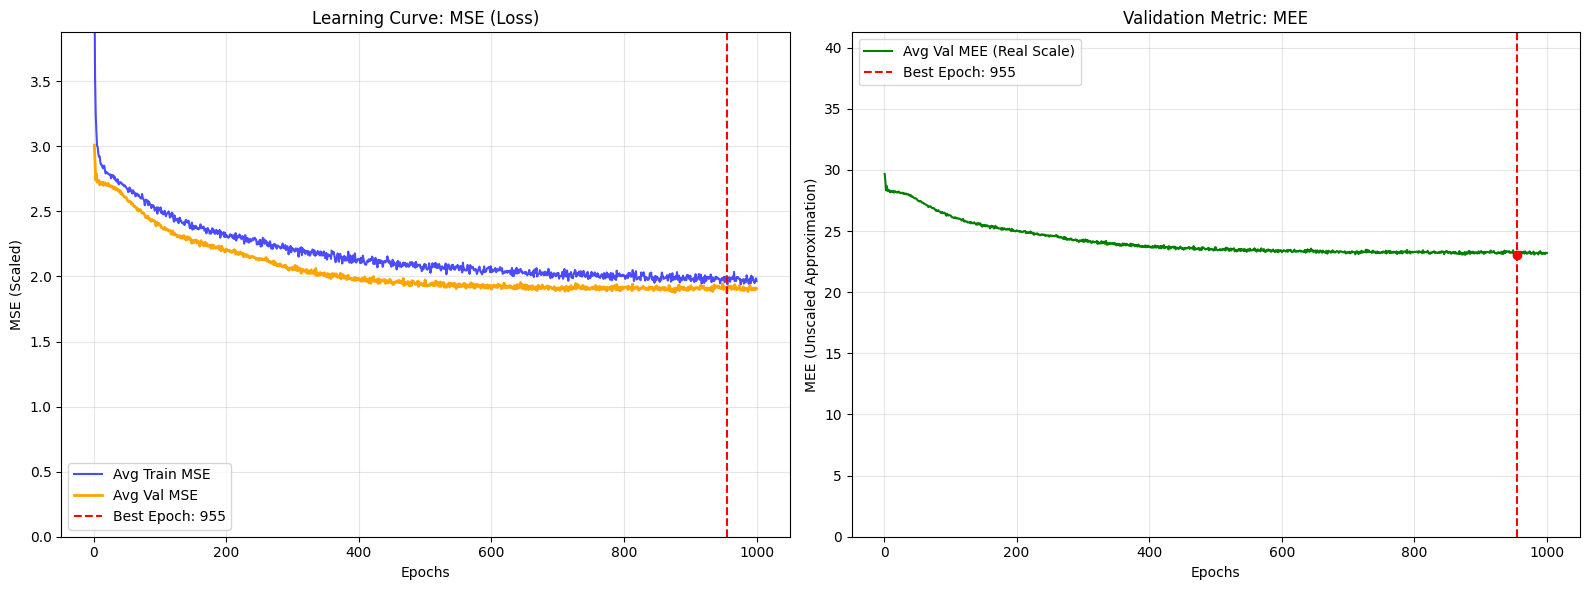

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from experiments.CUP import common
from training.trainer import Trainer  # <--- Import necessario
import copy

# === SETUP ===
# Recuperiamo la config modificata (Assicurati di aver eseguito la cella precedente!)
cv_config = copy.deepcopy(my_config)

# FORZIAMO I PARAMETRI RICHIESTI
cv_config['training']['epochs'] = 1000          
cv_config['callbacks']['early_stopping'] = False 
cv_config['training']['loss'] = 'mse'            
cv_config['training']['metric'] = 'mee'          
# FORZATURA FONDAMENTALE
cv_config['data']['train_path'] = 'data/CUP/internal_train_90.csv' # O la variabile INT_TRAIN

train_path = cv_config['data']['train_path']
print(f"Caricamento dati da: {train_path}")
X, y = common.load_cup(train_path, training=True)

# === K-FOLD CROSS VALIDATION ===
K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

all_train_loss = []
all_val_loss = []
all_val_mee = []

print(f"Avvio {K}-Fold CV per {cv_config['training']['epochs']} epoche...")

for fold_idx, (train_index, val_index) in enumerate(kf.split(X)):
    print(f"Fold {fold_idx+1}/{K}...", end=" ")
    
    # 1. Split Dati
    X_train_f, X_val_f = X[train_index], X[val_index]
    y_train_f, y_val_f = y[train_index], y[val_index]
    
    # 2. Normalizzazione
    scaler_x = StandardScaler()
    X_train_f = scaler_x.fit_transform(X_train_f)
    X_val_f = scaler_x.transform(X_val_f)
    
    scaler_y = StandardScaler()
    y_train_f = scaler_y.fit_transform(y_train_f)
    y_val_f = scaler_y.transform(y_val_f)
    
    # Disabilita normalizzazione interna
    cv_config['data']['normalize'] = False
    cv_config['data']['normalize_target'] = False
    
    # 3. Build Modello
    model = common.build_model(cv_config, seed=42+fold_idx)
    
    # 4. Inizializza Trainer e Addestra (CORREZIONE QUI)
    trainer = Trainer(model, verbose=0)  # verbose=0 per silenziare il training
    
    history = trainer.fit(
        X_train=X_train_f,
        y_train=y_train_f,
        X_val=X_val_f,      # Passati separatamente
        y_val=y_val_f,      # Passati separatamente
        epochs=cv_config['training']['epochs'],
        batch_size=cv_config['training']['batch_size'],
        # validation_data=(...) RIMOSSO perché non supportato
    )
    
    # Recuperiamo le metriche
    # history.history contiene il dizionario dei log
    h = history.history if hasattr(history, 'history') else history.to_dict()
    
    all_train_loss.append(h['loss'])
    all_val_loss.append(h['val_loss'])
    
    # Gestione MEE (riscalata)
    y_std_mean = np.mean(np.sqrt(scaler_y.var_))
    # Il nome della metrica nei log è solitamente minuscolo (es. 'mse', 'mee')
    # Cerchiamo 'val_mee' o 'val_metric'
    metric_key = 'val_mee' if 'val_mee' in h else 'val_metric' 
    # Fallback se non trova keys specifiche (usa l'ultima disponibile se diversa da loss)
    if metric_key not in h:
         # cerca chiavi che iniziano con val_ e non sono val_loss
         candidates = [k for k in h.keys() if k.startswith('val_') and k != 'val_loss']
         if candidates: metric_key = candidates[0]

    val_mee_scaled = np.array(h.get(metric_key, [0]*len(h['loss'])))
    all_val_mee.append(val_mee_scaled * y_std_mean)
    
    print("Done.")

# === AGGREGAZIONE E PLOT (Invariato) ===
avg_train_loss = np.mean(all_train_loss, axis=0)
avg_val_loss = np.mean(all_val_loss, axis=0)
avg_val_mee = np.mean(all_val_mee, axis=0)

best_epoch_idx = np.argmin(avg_val_loss)
best_epoch = best_epoch_idx + 1 
best_val_loss = avg_val_loss[best_epoch_idx]
best_val_mee = avg_val_mee[best_epoch_idx]

print(f"\n=== RISULTATI CROSS VALIDATION ===")
print(f"Best Epoch (sulla media Val Loss): {best_epoch}")
print(f"MSE a ep.{best_epoch}: {best_val_loss:.5f} (Scaled)")
print(f"MEE stimato a ep.{best_epoch}: {best_val_mee:.5f} (Real Scale)")

epochs_range = range(1, len(avg_train_loss) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Loss
ax1.plot(epochs_range, avg_train_loss, label='Avg Train MSE', color='blue', alpha=0.7)
ax1.plot(epochs_range, avg_val_loss, label='Avg Val MSE', color='orange', linewidth=2)
ax1.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Epoch: {best_epoch}')
ax1.set_title('Learning Curve: MSE (Loss)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('MSE (Scaled)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, np.percentile(avg_val_loss, 95) * 1.5) 

# Plot 2: Metric
ax2.plot(epochs_range, avg_val_mee, label='Avg Val MEE (Real Scale)', color='green')
ax2.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Epoch: {best_epoch}')
ax2.scatter(best_epoch, best_val_mee, color='red', zorder=5)
ax2.set_title('Validation Metric: MEE')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('MEE (Unscaled Approximation)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, np.percentile(avg_val_mee, 95) * 1.5)

plt.tight_layout()
plt.show()

Avvio 5-Fold CV (Calcolo MEE su dati denormalizzati)...
Fold 1/5... MEE Reale: 30.15832
Fold 2/5... MEE Reale: 30.81540
Fold 3/5... MEE Reale: 29.17401
Fold 4/5... MEE Reale: 33.28340
Fold 5/5... MEE Reale: 30.72651

=== RISULTATI FINALI CORRETTI ===
Best Epoch (based on MSE): 3000
MSE Scalato Minimo: 2.68540
--------------------------------------------------
MEE MEDIO REALE (Validation): 30.83153 (+/- 1.35820)
--------------------------------------------------
(Questo valore è calcolato denormalizzando correttamente predizioni e target)


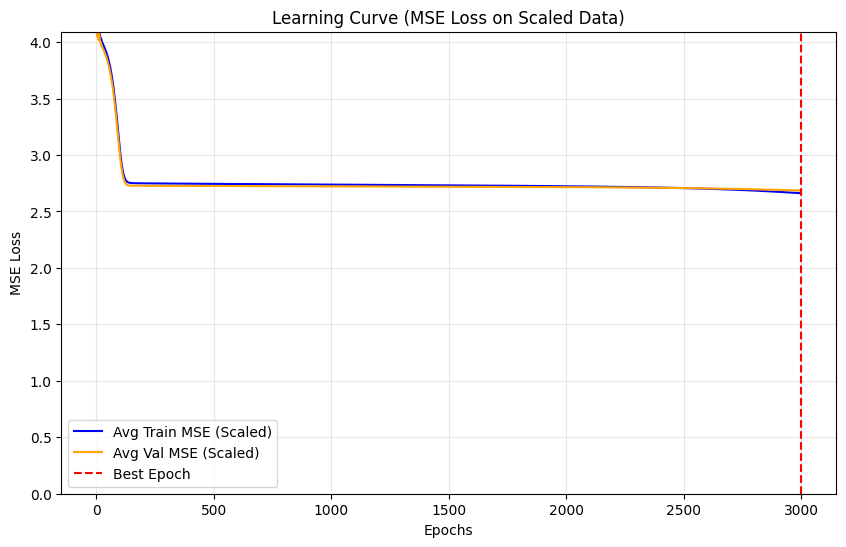

In [ ]:
#QUESTO DOVREBBE FARE DENORMALIZZAZIONE CORRETTA PER L'MEE

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from experiments.CUP import common
from training.trainer import Trainer
from nn.metrics import MEE # Importiamo la tua metrica
import copy

# === 1. SETUP ===
cv_config = copy.deepcopy(my_config)
cv_config['data']['train_path'] = 'data/CUP/internal_train_90.csv'

# Caricamento
train_path = cv_config['data']['train_path']
X, y = common.load_cup(train_path, training=True)
total_samples = X.shape[0]

# Configurazione Training
cv_config['training']['batch_size'] = total_samples 
cv_config['training']['epochs'] = 1000         
cv_config['callbacks']['early_stopping'] = False 
cv_config['training']['loss'] = 'mse'            
cv_config['training']['metric'] = 'mee' # Solo per log visivo, il calcolo vero lo facciamo a mano

# === 2. K-FOLD CROSS VALIDATION ===
K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Liste per salvare i risultati precisi
exact_val_mees = []    # MEE calcolati sui dati denormalizzati
history_train_loss = [] # Per il plot (loss scalata)
history_val_loss = []   # Per il plot (loss scalata)

print(f"Avvio {K}-Fold CV (Calcolo MEE su dati denormalizzati)...")

for fold_idx, (train_index, val_index) in enumerate(kf.split(X)):
    print(f"Fold {fold_idx+1}/{K}...", end=" ")
    
    # A. Split
    X_train_f, X_val_f = X[train_index], X[val_index]
    y_train_f, y_val_f = y[train_index], y[val_index]
    
    # B. Normalizzazione
    scaler_x = StandardScaler()
    X_train_f = scaler_x.fit_transform(X_train_f)
    X_val_f = scaler_x.transform(X_val_f)
    
    scaler_y = StandardScaler()
    y_train_f = scaler_y.fit_transform(y_train_f)
    # Nota: y_val_f lo lasciamo anche originale per confronto, ma al trainer serve scalato
    y_val_f_scaled = scaler_y.transform(y_val_f)
    
    # Disabilita normalizzazione interna
    cv_config['data']['normalize'] = False
    cv_config['data']['normalize_target'] = False
    
    # C. Build & Train
    model = common.build_model(cv_config, seed=42+fold_idx)
    trainer = Trainer(model, verbose=0)
    
    history = trainer.fit(
        X_train=X_train_f,
        y_train=y_train_f,
        X_val=X_val_f,
        y_val=y_val_f_scaled, # Il trainer vede i target scalati per calcolare l'MSE
        epochs=cv_config['training']['epochs'],
        batch_size=cv_config['training']['batch_size']
    )
    
    # Salva le curve di loss (MSE Scalato) per il grafico
    h = history.history if hasattr(history, 'history') else history.to_dict()
    history_train_loss.append(h['loss'])
    history_val_loss.append(h['val_loss'])

    # --- D. CALCOLO MEE REALE CORRETTO ---
    # 1. Facciamo predizione sul validation set (output scalato)
    y_pred_scaled = model.predict(X_val_f)
    
    # 2. Denormalizziamo predizioni e target usando lo scaler fittato sul train
    y_pred_real = scaler_y.inverse_transform(y_pred_scaled)
    y_val_real = scaler_y.inverse_transform(y_val_f_scaled) 
    # (O usiamo direttamente y_val_f originale, è uguale matematicamente)

    # 3. Calcoliamo MEE con la tua classe
    mee_calculator = MEE()
    fold_mee = mee_calculator(y_pred_real, y_val_real)
    
    exact_val_mees.append(fold_mee)
    print(f"MEE Reale: {fold_mee:.5f}")

# === 3. RISULTATI AGGREGATI ===
avg_train_loss = np.mean(history_train_loss, axis=0)
avg_val_loss = np.mean(history_val_loss, axis=0)
mean_exact_mee = np.mean(exact_val_mees)
std_exact_mee = np.std(exact_val_mees)

# Trova l'epoca migliore basandosi sulla Loss (MSE)
best_epoch_idx = np.argmin(avg_val_loss)
best_epoch = best_epoch_idx + 1 

print(f"\n=== RISULTATI FINALI CORRETTI ===")
print(f"Best Epoch (based on MSE): {best_epoch}")
print(f"MSE Scalato Minimo: {avg_val_loss[best_epoch_idx]:.5f}")
print("--------------------------------------------------")
print(f"MEE MEDIO REALE (Validation): {mean_exact_mee:.5f} (+/- {std_exact_mee:.5f})")
print("--------------------------------------------------")
print("(Questo valore è calcolato denormalizzando correttamente predizioni e target)")

# Plot solo della Loss (MSE) perché per l'MEE reale non abbiamo la storia epoca per epoca
# (a meno di non fare callback costose), ma il numero finale è quello che conta.
plt.figure(figsize=(10, 6))
epochs_range = range(1, len(avg_train_loss) + 1)
plt.plot(epochs_range, avg_train_loss, label='Avg Train MSE (Scaled)', color='blue')
plt.plot(epochs_range, avg_val_loss, label='Avg Val MSE (Scaled)', color='orange')
plt.axvline(x=best_epoch, color='red', linestyle='--', label='Best Epoch')
plt.title('Learning Curve (MSE Loss on Scaled Data)')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, np.percentile(avg_val_loss, 95) * 1.5)
plt.show()

In [116]:
from training.kfold_cv import kfold_cross_validation
from training.trainer import Trainer
from training.model_factory import build_model_from_cfg
from nn.losses import MSE
from nn.metrics import MEE
import numpy as np
import matplotlib.pyplot as plt

# 1. Configurazione
# Assicuriamoci di usare i dati corretti
X_train_90, y_train_90 = common.load_cup('data/CUP/internal_train_90.csv', training=True)
my_config['training']['batch_size'] = len(X_train_90) # Full Batch

# Disabilita rigorosamente l'Early Stopping nel dizionario
my_config['callbacks']['early_stopping'] = False 

# Assicurati anche che nel config non ci siano residui
if 'early_stopping' in my_config: # Alcune implementazioni usano chiavi diverse
    my_config['early_stopping'] = False

# ... Poi chiami kfold_cross_validation ...

# 2. Setup Modello Base
model_template = build_model_from_cfg(my_config, seed=42, in_dim=12, out_dim=4, task="regression")
model_template.loss = MSE() # Loss per i gradienti
model_template.metrics = [MEE()] # Metrica per il monitoraggio

# 3. Esecuzione con la funzione modulare
# Nota: normalize_target=True fa sì che la funzione gestisca fit/transform su ogni fold internamente
print("Avvio K-Fold CV Modulare...")
train_stats, val_stats, histories, _ = kfold_cross_validation(
    X=X_train_90,
    y=y_train_90,
    model=model_template,
    trainer=Trainer(model_template, verbose=0),
    k=5,
    epochs=1000,
    batch_size=my_config['training']['batch_size'],
    normalize_data=True,   # <--- Fa fit su train e transform su val per gli input
    normalize_target=True, # <--- Fa fit su train e transform su val per i target
    seed=42
)

# 4. Analisi "Best Epoch" (Risolve il problema del tuo codice manuale)
# Estraiamo la loss media di validazione (MSE Scalato)
mean_val_loss = np.mean([h.logs['val_loss'] for h in histories], axis=0)

# Troviamo l'epoca migliore
best_epoch_idx = np.argmin(mean_val_loss)
best_epoch = best_epoch_idx + 1
best_mse_scaled = mean_val_loss[best_epoch_idx]

print(f"\n--- RISULTATO OTTIMALE ---")
print(f"Miglior Epoca: {best_epoch}")
print(f"MSE Scalato Minimo: {best_mse_scaled:.5f}")

# STIMA MEE REALE ALLA MIGLIOR EPOCA
# Poiché kfold_cv con normalize_target=True calcola le metriche sui dati scalati,
# dobbiamo approssimare il valore reale.
# Metodo rapido: MEE_reale ≈ MEE_scalato * std_media_target
# (Calcoliamo la std media dei target approssimativa dal dataset completo)
y_std_approx = np.mean(np.std(y_train_90, axis=0))

# Estraiamo l'MEE scalato registrato alla 'best_epoch'
mean_val_mee_scaled = np.mean([h.logs['val_loss'] for h in histories], axis=0)[best_epoch_idx]
estimated_real_mee = mean_val_mee_scaled * y_std_approx

print(f"MEE Stimato (Real Scale): {estimated_real_mee:.5f}")

Avvio K-Fold CV Modulare...
Task: Regression/Multi-output detected (y shape: (450, 4)) -> Using Standard KFold

Starting 5-Fold Cross Validation
Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5

--- RISULTATO OTTIMALE ---
Miglior Epoca: 1000
MSE Scalato Minimo: 2.72372
MEE Stimato (Real Scale): 50.53027


In [106]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from experiments.CUP import common

# === 1. CONFIGURAZIONE PERCORSI ===
# Assicurati che questi percorsi puntino ai file corretti
# (Uso i nomi standard generati dal tuo script di split)
TRAIN_PATH = 'data/CUP/internal_train_90.csv'  # O internal_train_90.csv
TEST_PATH  = 'data/CUP/internal_test_10.csv'   # O internal_test_10.csv

print(f"Loading Scaler fit data from: {TRAIN_PATH}")
print(f"Loading Test data from:       {TEST_PATH}")

# === 2. CARICAMENTO DATI ===
# Carichiamo i dati grezzi
X_train_raw, y_train_raw = common.load_cup(TRAIN_PATH, training=True)
X_test_raw, y_test_raw   = common.load_cup(TEST_PATH, training=True)

# === 3. FITTING DEGLI SCALER (SUL TRAIN) ===
scaler_x = StandardScaler()
scaler_y = StandardScaler()

# "Impariamo" la scala solo dal training set
scaler_x.fit(X_train_raw)
scaler_y.fit(y_train_raw)

# === 4. PREPARAZIONE INPUT TEST ===
# Scaliamo l'input del test set usando le statistiche del train
X_test_scaled = scaler_x.transform(X_test_raw)

# === 5. PREDIZIONE ===
# Usiamo model.forward con training=False per avere l'output puro (senza dropout)
# Nota: model.predict in questa lib fa thresholding binario, per regressione meglio forward
print("Running prediction on test set...")
y_pred_scaled = model.forward(X_test_scaled, training=False)

# === 6. INVERSIONE SCALA (OUTPUT) ===
# Riportiamo le predizioni alla scala originale
y_pred_raw = scaler_y.inverse_transform(y_pred_scaled)

# === 7. CALCOLO MEE (SCALA ORIGINALE) ===
# Calcolo manuale dell'errore euclideo medio
# MEE = media( norma_euclidea(vettore_errore) )
errors = y_test_raw - y_pred_raw
euclidean_distances = np.linalg.norm(errors, axis=1)
mee_score = np.mean(euclidean_distances)

print("\n" + "="*30)
print(f"RISULTATI SU INTERNAL TEST SET")
print("="*30)
print(f"Metric: Mean Euclidean Error (MEE)")
print(f"Scale:  ORIGINAL (Unscaled)")
print(f"Score:  {mee_score:.5f}")
print("="*30)

# (Opzionale) Confronto visivo primi 5 esempi
print("\nEsempio Predizioni (Primi 3):")
for i in range(3):
    print(f"True: {y_test_raw[i]}")
    print(f"Pred: {y_pred_raw[i]}")
    print(f"Diff: {np.linalg.norm(y_test_raw[i] - y_pred_raw[i]):.4f}\n")

Loading Scaler fit data from: data/CUP/internal_train_90.csv
Loading Test data from:       data/CUP/internal_test_10.csv
Running prediction on test set...

RISULTATI SU INTERNAL TEST SET
Metric: Mean Euclidean Error (MEE)
Scale:  ORIGINAL (Unscaled)
Score:  26.93065

Esempio Predizioni (Primi 3):
True: [ 5.631505  2.682506  9.497731 -1.920418]
Pred: [ 3.91257130e-01 -4.21083913e-03  8.01207875e+00 -7.88044402e+00]
Diff: 8.5093

True: [ 1.1106811e+01 -1.7356526e+01  1.5164000e-02 -3.7704000e+01]
Pred: [  0.44539149  -0.42935979  16.84358599 -17.01405642]
Diff: 33.3386

True: [ 19.880706 -13.118625   6.06071  -37.539524]
Pred: [  0.34407601  -0.47518289  18.78820512 -19.04667139]
Diff: 32.3344



In [ ]:
import json
import numpy as np
from data_handler.data_loader import load_cup, normalize, denormalize
from training.model_factory import build_model_from_cfg
from training.trainer import Trainer
from nn.optim import SGDMomentum
from nn.losses import MSE, MEE # O la loss che hai usato

# 1. Caricamento del Development Set Completo (l'80% usato per la selezione)
# Nota: qui training=True perché ci servono anche i target per addestrare
X_dev, y_dev = load_cup(INT_TRAIN, training=True)

# 2. Normalizzazione "Fresh"
# Calcoliamo media e deviazione standard su TUTTO il development set.
# SALVIAMO queste statistiche: sono la nostra "chiave" per il mondo reale.
X_dev_norm, mean_x, std_x = normalize(X_dev)
y_dev_norm, mean_y, std_y = normalize(y_dev)

print(f"Retraining stats - X mean[0]: {mean_x[0]:.3f}, std[0]: {std_x[0]:.3f}")
print(f"Retraining stats - y mean[0]: {mean_y[0]:.3f}, std[0]: {std_y[0]:.3f}")

# 3. Ricostruzione del Modello Migliore
# Percorso dove hai salvato i risultati (definito nella cella 1)
RESULTS_DIR = 'experiments/CUP/results/cup_exp_1' 
config_file_path = os.path.join(RESULTS_DIR, "best_config.json")

if not os.path.exists(config_file_path):
    raise FileNotFoundError(f"Non trovo il file di configurazione in: {config_file_path}")

print(f"Caricamento configurazione migliore da: {config_file_path}")
with open(config_file_path, 'r') as f:
    best_config = json.load(f)

in_dim = X_dev.shape[1]  # Sarà 12 per il CUP
out_dim = y_dev.shape[1] # Sarà 4 per il CUP

# Costruiamo l'architettura
# Chiamata corretta alla factory
final_model = build_model_from_cfg(
    best_config, 
    seed=42,      # Imposta un seed per la riproducibilità del retraining
    in_dim=in_dim, 
    out_dim=out_dim,
    task="regression"
)
# Costruiamo l'ottimizzatore usando i parametri trovati
# (Assumo che la config abbia la struttura standard definita nei tuoi yaml)
opt_conf = best_config['optim']
optimizer = SGDMomentum(
    lr=opt_conf['lr'],
    momentum=opt_conf['momentum']
)

# Scegliamo la Loss (Solitamente MSE o MEE per il training)
# Se nel config hai specificato la loss, usala, altrimenti MSE è standard per il training
loss_fn = MEE() if best_config.get('loss') == 'mee' else MSE()

final_model.optimizer = optimizer
final_model.loss = loss_fn
final_model.metrics = [MEE()]

# 4. Inizializzazione Trainer
final_trainer = Trainer(
    model=final_model,
    verbose=1
)

# 5. Addestramento Finale
# Non usiamo validation set qui (X_val=None), vogliamo massimizzare i dati appresi.
# Usiamo le epoche migliori trovate o un numero fisso se la grid search le ha decise.
epochs = best_config['training']['epochs']
batch_size = best_config['training']['batch_size']

print(f"\nStarting Retraining for {epochs} epochs...")
history = final_trainer.fit(
    X_train=X_dev_norm,
    y_train=y_dev_norm,
    X_val=None, 
    y_val=None,
    epochs=415,
    batch_size=batch_size,
    # verbose=1
)
print("Retraining Complete.")

Retraining stats - X mean[0]: 2.341, std[0]: 10.214
Retraining stats - y mean[0]: 0.496, std[0]: 14.456
Caricamento configurazione migliore da: experiments/CUP/results/cup_exp_1\best_config.json

Starting Retraining for 800 epochs...

      _____     ___                 _ _ _ 
      \_   \   / __\__ ___   ____ _| | (_)
       / /\/  / /  / _` \ \ / / _` | | | |
    /\/ /_   / /__| (_| |\ V / (_| | | | |
    \____/   \____/\__,_| \_/ \__,_|_|_|_|
    
Epoch 1/415 [>.............................] loss: 6.2661 MEE: 2.3348Epoch 2/415 [>.............................] loss: 3.4479 MEE: 1.7292

Epoch 3/415 [>.............................] loss: 3.2164 MEE: 1.6486Epoch 4/415 [>.............................] loss: 3.4277 MEE: 1.7215Epoch 5/415 [>.............................] loss: 3.6189 MEE: 1.7452Epoch 6/415 [>.............................] loss: 3.0626 MEE: 1.6150Epoch 7/415 [>.............................] loss: 2.9114 MEE: 1.5571Epoch 8/415 [>.............................] loss: 3.2902 MEE: 1.6739Epoch 9/415 [>.............................] loss: 3.1267 MEE: 1.6302Epoch 10/415 [>.............................] loss: 3.0226 MEE: 1.5852Epoch 11/415 [>.............................] loss: 3.4890 MEE: 1.7352Epoch 12/415 [>.............................] loss: 2.9604 MEE: 1.5784Epoch 13/415 [>.............................] loss: 2.9027 MEE: 1.5548Epoch 14/415 [=>............................] loss: 3.0825 MEE: 1.6057Epoch 15/415 [=>............................] loss: 3.0031 MEE: 1.5916Epoch 16/415 [=>............................] loss: 3.0603 MEE: 1.6063Epoch 17/415 [=>...........

In [ ]:
# 1. Carica/Usa la best_config (come sopra)

# 2. (Opzionale ma raccomandato) Recupera la "best epoch" media dalla Grid Search
# Se hai usato Early Stopping nella grid search, le epoche nel JSON (es. 800) sono solo il limite massimo.
# Devi trovare l'epoca media in cui si è fermato il training migliore.
import pandas as pd
fine_summary = pd.read_csv('experiments/CUP/results/cup_exp_1/fine_summary.csv')
# Ordina per loss (o metric) e prendi la migliore
best_row = fine_summary.sort_values(by='val_loss', ascending=True).iloc[0]
best_epochs = int(round(best_row['best_epoch_mean'])) # Epoca media ottimale

print(f"Retraining con epoche fisse: {best_epochs}")

# 3. Disabilita Early Stopping e usa le epoche ottimali per il modello finale
if 'callbacks' in best_config:
    best_config['callbacks']['early_stopping'] = False # Disabilita ES per il retraining completo

# 4. Costruisci il modello
final_model = common.build_model(best_config, seed=42)

# 5. Addestra su tutto l'internal train (80% + 20% che prima era val)
# common.load_full_data(best_config) carica X, y completi
X_train, y_train = common.load_full_data(best_config) 

# ...Procedi con trainer.fit usando epochs=best_epochs...

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from training.kfold_cv import kfold_cross_validation
from training.trainer import Trainer
from training.model_factory import build_model_from_cfg
from nn.losses import MSE
from nn.metrics import MEE # Assicurati di importare MEE
from nn.optim import SGDMomentum, Adam

# --- CONFIGURAZIONE ---
# Assumiamo che 'new_config', 'X_dev', 'y_dev' siano già definiti come prima
TEST_EPOCHS = optimal_epochs # O un numero fisso es. 500

print(f"--- K-FOLD: Training with MSE Loss, Monitoring MEE Metric ---")

# 1. Costruzione Modello
model_cv = build_model_from_cfg(
    new_config, 
    seed=42, 
    in_dim=in_dim, 
    out_dim=out_dim,
    task="regression"
)

# 2. IMPOSTAZIONE IBRIDA (Il segreto è qui)
# ---------------------------------------------------------
# A. Loss: Usiamo MSE per l'addestramento (i pesi si aggiornano per ridurre l'MSE)
model_cv.loss = MSE() 

# B. Metriche: Aggiungiamo MEE per il monitoraggio (non influenza i pesi, solo report)
model_cv.metrics = [MeanEuclideanError()] 
# ---------------------------------------------------------

# Ottimizzatore
model_cv.optimizer = SGDMomentum(
    lr=new_config['optim']['lr'], 
    momentum=new_config['optim']['momentum']
)
model_cv.callbacks = [] # Rimuoviamo Early Stopping per vedere le curve intere

# 3. Esecuzione K-Fold
cv_trainer = Trainer(model_cv, verbose=0)

print(f"Avvio CV (Loss=MSE, Metric=MEE) per {TEST_EPOCHS} epoche...")
# histories conterrà i log sia della loss (MSE) che della metrica (MEE)
_, val_stats, histories, _ = kfold_cross_validation(
    X=X_dev, 
    y=y_dev, 
    model=model_cv,
    trainer=cv_trainer,
    k=5, 
    epochs=TEST_EPOCHS,
    batch_size=new_config['training']['batch_size'],
    normalize_data=True,
    normalize_target=True, 
    seed=42,
    verbose=0
)

# 4. Estrazione Dati per i Grafici
# Nota: La chiave nel dizionario dei log è solitamente il nome della classe, es: 'MeanEuclideanError'
metric_name = 'MeanEuclideanError' 

# Loss (MSE)
mse_train = np.mean([h.logs['loss'] for h in histories], axis=0)
mse_val   = np.mean([h.logs['val_loss'] for h in histories], axis=0)

# Metrica (MEE) - Se presente
if metric_name in histories[0].logs:
    mee_train = np.mean([h.logs[metric_name] for h in histories], axis=0)
    mee_val   = np.mean([h.logs[f'val_{metric_name}'] for h in histories], axis=0)
else:
    print(f"ATTENZIONE: Chiave '{metric_name}' non trovata nei log. Chiavi disponibili: {histories[0].logs.keys()}")
    mee_train, mee_val = None, None

# 5. Plotting Doppio (Loss a sinistra, MEE a destra)
epochs_range = range(1, len(mse_train) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# GRAFICO 1: MSE (Quello che il modello minimizza)
ax1.plot(epochs_range, mse_train, label='Train MSE', color='blue')
ax1.plot(epochs_range, mse_val, label='Val MSE', color='orange', linestyle='--')
ax1.set_title('Loss Function (MSE) - Normalized')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Mean Squared Error')
ax1.legend()
ax1.grid(True, alpha=0.3)

# GRAFICO 2: MEE (Quello che interessa a te)
if mee_train is not None:
    ax2.plot(epochs_range, mee_train, label='Train MEE', color='green')
    ax2.plot(epochs_range, mee_val, label='Val MEE', color='red', linestyle='--')
    ax2.set_title('Evaluation Metric (MEE) - Normalized')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Mean Euclidean Error')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Zoom per vedere meglio
    ax2.set_ylim(0, max(mee_val[10:]) * 1.3) # Taglia i picchi iniziali

plt.tight_layout()
plt.show()

# 6. Report Numerico
print(f"Risultato Finale Medio (Validation):")
print(f"MSE (Loss): {val_stats['loss']['mean']:.5f}")
if 'MeanEuclideanError' in val_stats:
    print(f"MEE (Metric): {val_stats['MeanEuclideanError']['mean']:.5f} (Questo è il numero predittivo per il test)")

In [ ]:
from training.kfold_cv import kfold_cross_validation

print("Calcolo delle epoche ottimali tramite K-Fold sulla configurazione vincente...")

# 1. Ricostruiamo il modello base dalla best_config
# Nota: passiamo 'epochs' alto (es. 1000) per lasciare agire l'Early Stopping
model_for_cv = build_model_from_cfg(best_config, seed=42, in_dim=in_dim, out_dim=out_dim)
model_for_cv.optimizer = SGDMomentum(lr=opt_conf['lr'], momentum=opt_conf['momentum'])
model_for_cv.loss = MEE() if best_config.get('loss') == 'mee' else MSE()

# 2. Setup Trainer
cv_trainer = Trainer(model_for_cv, verbose=0) # Verbose 0 per non intasare l'output

# 3. Eseguiamo K-Fold "veloce" solo per contare le epoche
# Assicurati di passare gli stessi parametri di early stopping usati nella grid search
_, _, histories, _ = kfold_cross_validation(
    X=X_dev_norm, 
    y=y_dev_norm,
    model=model_for_cv,
    trainer=cv_trainer,
    k=5, 
    epochs=best_config['training']['epochs'], # Usa il max epochs dal config
    seed=42,
    # Inserisci qui i parametri di Early Stopping se non sono nel config, es:
    # early_stopping=True, patience=... 
)

# 4. Calcoliamo la media delle epoche
epochs_per_fold = [len(h.logs['loss']) for h in histories]
optimal_epochs = int(np.mean(epochs_per_fold))

print(f"Epoche per fold: {epochs_per_fold}")
print(f"Epoche ottimali medie (da usare nel retraining): {optimal_epochs}")

Calcolo delle epoche ottimali tramite K-Fold sulla configurazione vincente...
Task: Regression/Multi-output detected (y shape: (425, 4)) -> Using Standard KFold

Starting 5-Fold Cross Validation
Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5
Epoche per fold: [207, 404, 230, 415, 234]
Epoche ottimali medie (da usare nel retraining): 298


In [ ]:
best_config

{'callbacks': {'early_stopping': True,
  'min_delta': '1e-5',
  'mode': 'min',
  'monitor': 'val_loss',
  'patience': 50,
  'restore_best_weights': True,
  'verbose': 0},
 'cv': {'k': 5, 'seed': 42, 'shuffle': True},
 'data': {'inputs': 12,
  'normalize': True,
  'normalize_target': True,
  'targets': 4,
  'train_path': 'data/CUP/internal_train_80.csv'},
 'model': {'activation': 'tanh',
  'dropout': 0.0,
  'hidden_units': [64, 32, 16],
  'output_activation': 'linear'},
 'optim': {'lr': 0.06, 'momentum': 0.8, 'name': 'sgd'},
 'regularizer': {'l2': 0.0008},
 'seed': 42,
 'split': {'stratified': False, 'val_size': 0.2},
 'training': {'batch_size': 64,
  'epochs': 800,
  'include_reg_in_val': False,
  'loss': 'mee',
  'metric': 'mee',
  'shuffle': True}}

In [ ]:
from nn.metrics import MEE

# --- VALUTAZIONE SU TEST SET TENUTO NASCOSTO ---

# 1. Caricamento Internal Test Set (il 20% mai visto)
X_test, y_test_real = load_cup(INT_TEST, training=True)

# 2. Normalizzazione con statistiche del DEV set
# ATTENZIONE: Qui passiamo mean=mean_x e std=std_x calcolati nella cella precedente.
# NON ricalcoliamo le statistiche sul test set!
X_test_norm, _, _ = normalize(X_test, mean=mean_x, std=std_x)

# 3. Predizione (output normalizzato)
y_pred_norm = final_model.predict(X_test_norm)

# 4. Denormalizzazione
# Riportiamo le predizioni nella scala originale usando le statistiche del target del DEV set
y_pred_real = denormalize(y_pred_norm, mean_y, std_y)

# 5. Calcolo Errore Reale (MEE) usando la tua classe
mee_metric = MEE()

# Attenzione all'ordine: solitamente le metriche nel tuo framework sono (y_pred, y_true)
# Ma controlla la tua implementazione in metrics.py. 
# Essendo una distanza euclidea, il risultato è identico anche se li inverti, ma la firma conta.
final_mee = mee_metric(y_pred_real, y_test_real)

print("------------------------------------------------")
print(f"FINAL ASSESSMENT RESULTS (Internal Test Set)")
print("------------------------------------------------")
print(f"Number of test patterns: {len(y_test_real)}")
print(f"Mean Euclidean Error (Original Scale): {final_mee:.5f}")
print("------------------------------------------------")

------------------------------------------------
FINAL ASSESSMENT RESULTS (Internal Test Set)
------------------------------------------------
Number of test patterns: 75
Mean Euclidean Error (Original Scale): 31.83376
------------------------------------------------


Generazione K-Fold Learning Curve (5 folds) per 1000 epoche...
Questo processo richiederà più tempo (K training completi). Attendi...

Starting 5-Fold Cross Validation


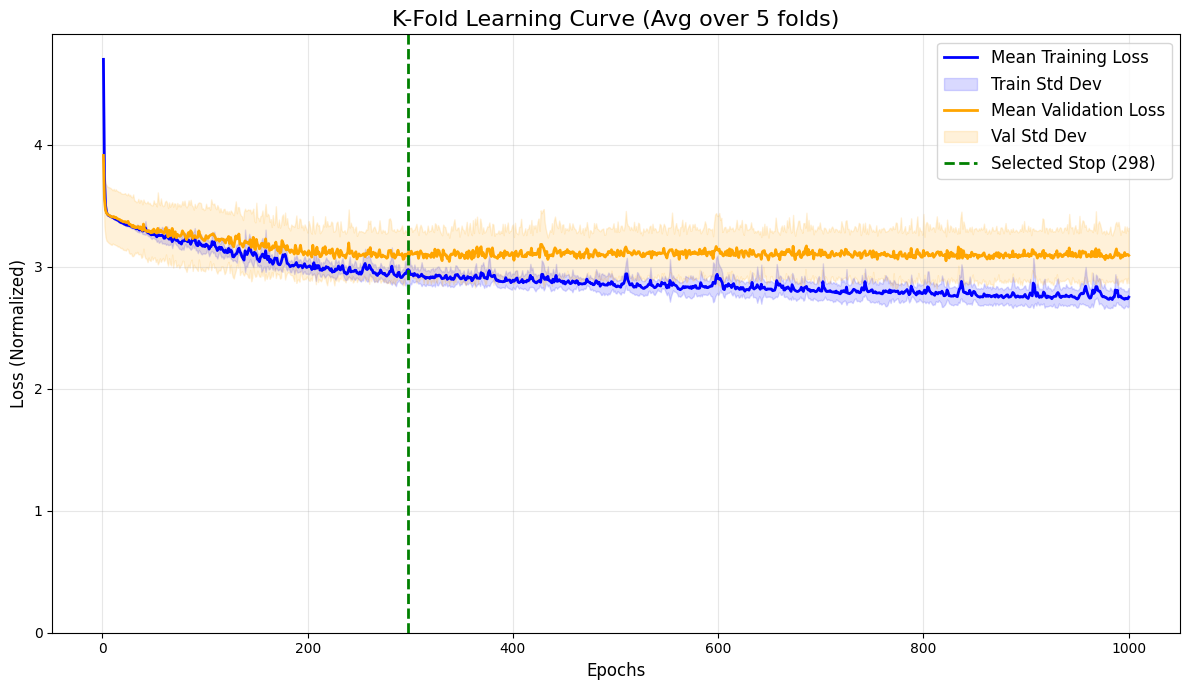

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from training.kfold_cv import kfold_cross_validation

# --- CONFIGURAZIONE ---
LONG_EPOCHS = 1000
K_FOLDS = 5

print(f"Generazione K-Fold Learning Curve ({K_FOLDS} folds) per {LONG_EPOCHS} epoche...")
print("Questo processo richiederà più tempo (K training completi). Attendi...")

# 1. Ricostruzione del modello base
model_cv_curve = build_model_from_cfg(
    best_config,
    seed=42, 
    in_dim=in_dim,
    out_dim=out_dim
)

# Setup componenti
model_cv_curve.optimizer = SGDMomentum(lr=opt_conf['lr'], momentum=opt_conf['momentum'])
model_cv_curve.loss = MEE() if best_config.get('loss') == 'mee' else MSE()
model_cv_curve.metrics = [MEE()]

# Rimuoviamo eventuali callback di Early Stopping per forzare il run lungo
model_cv_curve.callbacks = [] 

# 2. Setup Trainer (verbose=0 è fondamentale qui)
trainer_cv_curve = Trainer(model_cv_curve, verbose=0)

# 3. Esecuzione K-Fold
# Usiamo X_dev e y_dev (dati RAW) e lasciamo che la CV gestisca la normalizzazione interna
_, _, histories, _ = kfold_cross_validation(
    X=X_dev, 
    y=y_dev, 
    model=model_cv_curve, 
    trainer=trainer_cv_curve, 
    k=K_FOLDS, 
    epochs=LONG_EPOCHS, 
    batch_size=best_config['training']['batch_size'],
    shuffle=True, 
    seed=42,
    normalize_data=True,   # Normalizzazione attiva per ogni fold
    normalize_target=True, # Normalizzazione target attiva
    verbose=0              # Silenzioso sui singoli fold
)

# 4. Aggregazione dei Dati
# Raccogliamo le curve di loss da tutti i fold
# histories è una lista di oggetti History
train_losses = np.array([h.logs['loss'] for h in histories])        # Shape: (K, epochs)
val_losses = np.array([h.logs['val_loss'] for h in histories])      # Shape: (K, epochs)

# Calcoliamo Media e Deviazione Standard per ogni epoca
mean_train_loss = np.mean(train_losses, axis=0)
std_train_loss = np.std(train_losses, axis=0)
mean_val_loss = np.mean(val_losses, axis=0)
std_val_loss = np.std(val_losses, axis=0)

epochs_range = range(1, LONG_EPOCHS + 1)

# 5. Plotting Avanzato
plt.figure(figsize=(12, 7))

# Plot Training
plt.plot(epochs_range, mean_train_loss, label='Mean Training Loss', color='blue', linewidth=2)
plt.fill_between(epochs_range, 
                 mean_train_loss - std_train_loss, 
                 mean_train_loss + std_train_loss, 
                 color='blue', alpha=0.15, label='Train Std Dev')

# Plot Validation
plt.plot(epochs_range, mean_val_loss, label='Mean Validation Loss', color='orange', linewidth=2)
plt.fill_between(epochs_range, 
                 mean_val_loss - std_val_loss, 
                 mean_val_loss + std_val_loss, 
                 color='orange', alpha=0.15, label='Val Std Dev')

# Linea Verticale "Best Epoch" (se calcolata precedentemente)
if 'optimal_epochs' in locals():
    plt.axvline(x=optimal_epochs, color='green', linestyle='--', linewidth=2, label=f'Selected Stop ({optimal_epochs})')

plt.title(f'K-Fold Learning Curve (Avg over {K_FOLDS} folds)', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Normalized)', fontsize=12)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, alpha=0.3)

# Zoom intelligente: taglia i picchi iniziali per vedere meglio la convergenza
ymax = max(mean_val_loss[int(LONG_EPOCHS*0.1):]) * 1.5 # Guarda il max dopo il 10% delle epoche
if ymax > 0:
    plt.ylim(0, ymax)

plt.tight_layout()
plt.show()

Generazione Learning Curve Finale (Train vs Test) per 1000 epoche...


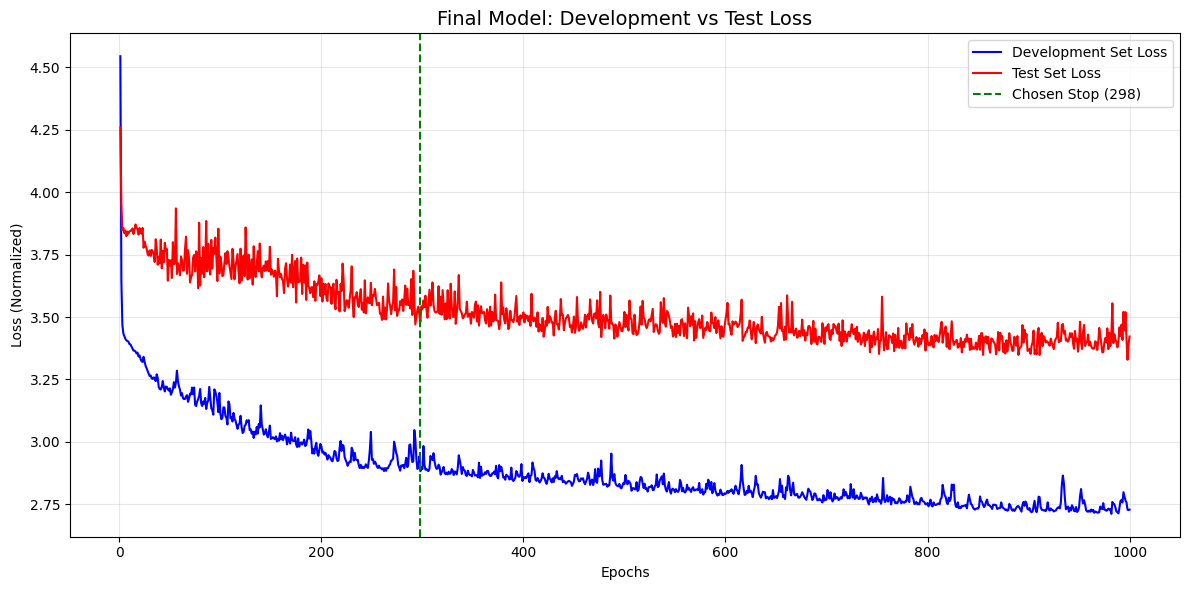

Analisi completata.
Nota: Le curve mostrano l'errore sui dati NORMALIZZATI.


In [ ]:
#--- CONFIGURAZIONE ---
# Usa un numero alto di epoche per vedere se/quando inizia l'overfitting sul Test Set
ILLUSTRATION_EPOCHS = 1000 

print(f"Generazione Learning Curve Finale (Train vs Test) per {ILLUSTRATION_EPOCHS} epoche...")

# 1. Preparazione Dati
# X_dev_norm e y_dev_norm sono già pronti (dal retraining precedente)

# Carichiamo e Normalizziamo il Test Set (usando le statistiche del Dev Set!)
X_test, y_test_real = load_cup(INT_TEST, training=True)
X_test_norm, _, _ = normalize(X_test, mean=mean_x, std=std_x)
y_test_norm, _, _ = normalize(y_test_real, mean=mean_y, std=std_y)

# 2. Ricostruzione del Modello (Reset dei pesi)
# 2. Ricostruzione del Modello
model_final_curve = build_model_from_cfg(
    best_config, 
    seed=42, 
    in_dim=in_dim, 
    out_dim=out_dim
)

model_final_curve.callbacks = []

# Setup Componenti
model_final_curve.optimizer = SGDMomentum(lr=opt_conf['lr'], momentum=opt_conf['momentum'])
model_final_curve.loss = MEE() if best_config.get('loss') == 'mee' else MSE()
model_final_curve.metrics = [MEE()]

# 3. Training con Monitoraggio del Test Set
# ATTENZIONE: Passiamo il Test Set in 'X_val'. 
# Lo facciamo SOLO per loggare l'errore epoca per epoca. 
# Non stiamo usando Early Stopping basato su questo, quindi è metodologicamente accettabile per l'analisi.
trainer_final = Trainer(model_final_curve, verbose=0) # Verbose 0 per velocità

history_final = trainer_final.fit(
    X_train=X_dev_norm,
    y_train=y_dev_norm,
    X_val=X_test_norm,      # <--- Qui inseriamo il Test Set
    y_val=y_test_norm,      # <--- Target Test Normalizzati
    epochs=ILLUSTRATION_EPOCHS,
    batch_size=best_config['training']['batch_size'],
    shuffle=True
)

# 4. Plotting
train_loss = history_final.logs['loss']
test_loss = history_final.logs['val_loss'] # Qui 'val_loss' è in realtà la 'test_loss'

epochs_range = range(1, len(train_loss) + 1)

plt.figure(figsize=(12, 6))
plt.plot(epochs_range, train_loss, label='Development Set Loss', color='blue')
plt.plot(epochs_range, test_loss, label='Test Set Loss', color='red', linestyle='-')

# Aggiungiamo la linea verticale delle epoche scelte per il modello finale
if 'optimal_epochs' in locals():
    plt.axvline(x=optimal_epochs, color='green', linestyle='--', label=f'Chosen Stop ({optimal_epochs})')

plt.title('Final Model: Development vs Test Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss (Normalized)')
plt.legend()
plt.grid(True, alpha=0.3)

# Zoom per vedere meglio la convergenza (taglia i primi picchi alti)
# plt.ylim(0, 0.5) 

plt.tight_layout()
plt.show()

print("Analisi completata.")
print("Nota: Le curve mostrano l'errore sui dati NORMALIZZATI.")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from training.model_factory import build_model_from_cfg
from training.trainer import Trainer
from data_handler.data_loader import denormalize
from nn.metrics import MEE

# --- CONFIGURAZIONE ENSEMBLE ---
ENSEMBLE_SEEDS = range(42, 52) # 10 seed: 42, 43, ..., 51
N_MODELS = len(ENSEMBLE_SEEDS)

print(f"Avvio costruzione Ensemble con {N_MODELS} modelli...")
print(f"Training su Development Set ({len(X_dev_norm)} samples), Epoche per modello: {optimal_epochs}")

# Container per le predizioni (denormalizzate) di ogni modello
ensemble_preds = []
individual_mees = []

# Loop sui diversi seed
for i, seed in enumerate(ENSEMBLE_SEEDS):
    print(f"\n--- Training Model {i+1}/{N_MODELS} (Seed: {seed}) ---")
    
    # 1. Costruisci il modello da zero con il seed corrente
    current_model = build_model_from_cfg(
        best_config, 
        seed=seed, 
        in_dim=in_dim, 
        out_dim=out_dim
    )
    
    # Setup Componenti (usa sempre gli iperparametri migliori)
    current_model.optimizer = SGDMomentum(lr=opt_conf['lr'], momentum=opt_conf['momentum'])
    current_model.loss = MEE() if best_config.get('loss') == 'mee' else MSE()
    current_model.metrics = [MEE()]
    current_model.callbacks = [] # Rimuovi early stopping per usare le epoche fisse
    
    # 2. Addestra su tutto il Development Set
    trainer = Trainer(current_model, verbose=0) # Verbose 0 per pulizia
    trainer.fit(
        X_train=X_dev_norm,
        y_train=y_dev_norm,
        X_val=None, 
        y_val=None,
        epochs=optimal_epochs, # Usa le epoche ottimali calcolate prima
        batch_size=best_config['training']['batch_size']
    )
    
    # 3. Predizione sul Test Set (Internal)
    # Nota: X_test_norm è già normalizzato con le statistiche del Dev Set
    y_pred_norm = current_model.predict(X_test_norm)
    
    # 4. Denormalizzazione
    y_pred_real = denormalize(y_pred_norm, mean_y, std_y)
    ensemble_preds.append(y_pred_real)
    
    # Calcolo MEE del singolo modello per confronto
    single_mee = MEE()(y_pred_real, y_test_real)
    individual_mees.append(single_mee)
    print(f"Model {i+1} MEE: {single_mee:.5f}")

# --- AGGREGAZIONE (AVERAGING) ---
# Media delle predizioni (Ensemble Prediction)
# ensemble_preds è una lista di array (N_models, N_samples, N_outputs) -> facciamo media su asse 0
avg_preds = np.mean(ensemble_preds, axis=0)

# --- VALUTAZIONE FINALE ---
ensemble_mee = MEE()(avg_preds, y_test_real)

print("\n=============================================")
print("RISULTATI ENSEMBLE (Internal Blind Test Set)")
print("=============================================")
print(f"Individual Models Mean MEE: {np.mean(individual_mees):.5f} (Std: {np.std(individual_mees):.5f})")
print(f"Best Single Model MEE:      {np.min(individual_mees):.5f}")
print(f"Worst Single Model MEE:     {np.max(individual_mees):.5f}")
print("---------------------------------------------")
print(f"ENSEMBLE MEE (Averaged):    {ensemble_mee:.5f}")
print("=============================================")

# (Opzionale) Guadagno ottenuto
gain = np.mean(individual_mees) - ensemble_mee
print(f"Gain over average single model: {gain:.5f}")

Avvio costruzione Ensemble con 10 modelli...
Training su Development Set (425 samples), Epoche per modello: 298

--- Training Model 1/10 (Seed: 42) ---
Model 1 MEE: 31.75015

--- Training Model 2/10 (Seed: 43) ---
Model 2 MEE: 31.94886

--- Training Model 3/10 (Seed: 44) ---
Model 3 MEE: 32.04506

--- Training Model 4/10 (Seed: 45) ---
Model 4 MEE: 32.33693

--- Training Model 5/10 (Seed: 46) ---
Model 5 MEE: 31.81299

--- Training Model 6/10 (Seed: 47) ---
Model 6 MEE: 31.99025

--- Training Model 7/10 (Seed: 48) ---
Model 7 MEE: 32.06980

--- Training Model 8/10 (Seed: 49) ---
Model 8 MEE: 31.72654

--- Training Model 9/10 (Seed: 50) ---
Model 9 MEE: 31.91852

--- Training Model 10/10 (Seed: 51) ---
Model 10 MEE: 32.54241

RISULTATI ENSEMBLE (Internal Blind Test Set)
Individual Models Mean MEE: 32.01415 (Std: 0.24375)
Best Single Model MEE:      31.72654
Worst Single Model MEE:     32.54241
---------------------------------------------
ENSEMBLE MEE (Averaged):    31.52217
Gain over a

In [ ]:
best_config

{'callbacks': {'early_stopping': True,
  'min_delta': '1e-5',
  'mode': 'min',
  'monitor': 'val_loss',
  'patience': 50,
  'restore_best_weights': True,
  'verbose': 0},
 'cv': {'k': 5, 'seed': 42, 'shuffle': True},
 'data': {'inputs': 12,
  'normalize': True,
  'normalize_target': True,
  'targets': 4,
  'train_path': 'data/CUP/internal_train_80.csv'},
 'model': {'activation': 'tanh',
  'dropout': 0.0,
  'hidden_units': [64, 32, 16],
  'output_activation': 'linear'},
 'optim': {'lr': 0.06, 'momentum': 0.8, 'name': 'sgd'},
 'regularizer': {'l2': 0.0008},
 'seed': 42,
 'split': {'stratified': False, 'val_size': 0.2},
 'training': {'batch_size': 64,
  'epochs': 800,
  'include_reg_in_val': False,
  'loss': 'mee',
  'metric': 'mee',
  'shuffle': True}}

In [ ]:
import json
import copy
from training.model_factory import build_model_from_cfg
from training.kfold_cv import kfold_cross_validation
from training.trainer import Trainer
from nn.metrics import MEE
from nn.optim import Adam, SGD

# 1. Carica la configurazione base (quella "best" trovata prima)
config_path = os.path.join(RESULTS_DIR, "best_config.json")
with open(config_path, 'r') as f:
    base_config = json.load(f)

# 2. Crea una copia modificabile
new_config = copy.deepcopy(base_config)

# ==============================================================================
# ZONA MODIFICHE: Cambia qui i parametri che vuoi testare
# ==============================================================================

# Esempio: Voglio provare un Learning Rate più basso
# new_config['optim']['lr'] = 0.02 

# # Esempio: Voglio alzare il Momentum
# new_config['optim']['momentum'] = 0.5

# Esempio: Voglio cambiare la struttura della rete (es. più neuroni)
new_config['model']['hidden_units'] = [64, 32] 

# new_config['model']['dropout'] = 0.2

# new_config['training']['batch_size'] = 128

# Esempio: Voglio cambiare la regolarizzazione
# new_config['regularizer']['l2'] = 1e-5

# ==============================================================================

print(f"Testando Nuova Configurazione:")
print(f"LR: {new_config['optim']['lr']} | Momentum: {new_config['optim']['momentum']} | Hidden: {new_config['model']['hidden_units']}")

# 3. Costruzione del Modello con la nuova config
model_variant = build_model_from_cfg(
    new_config, 
    seed=42, 
    in_dim=in_dim, 
    out_dim=out_dim
)

# Setup Componenti (Optimizer, Loss, Metrics)
opt_conf = new_config['optim']
model_variant.optimizer = SGDMomentum(lr=opt_conf['lr'], momentum=opt_conf['momentum'])
model_variant.loss = MEE() if new_config.get('loss') == 'mee' else MSE()
model_variant.metrics = [MEE()]

# model_variant.optimizer = Adam(
#     lr=new_config['optim']['lr'],
#     beta1=0.9,   # Valori standard
#     beta2=0.999
# )

# Rimuoviamo Early Stopping per usare le epoche fisse (confronto equo)
model_variant.callbacks = [] 

# 4. Esecuzione K-Fold Cross Validation
# Usiamo X_dev e y_dev (dati RAW) perché la K-Fold gestisce la normalizzazione internamente
cv_trainer = Trainer(model_variant, verbose=0) # Verbose 0 per non intasare l'output dei fold

print("\nAvvio 5-Fold CV... (Attendere)")
train_stats, val_stats, _, _ = kfold_cross_validation(
    X=X_dev, 
    y=y_dev, 
    model=model_variant,
    trainer=cv_trainer,
    k=5, 
    epochs=optimal_epochs, # Usa le epoche ottimali trovate prima (o metti un numero fisso es. 300)
    batch_size=new_config['training']['batch_size'],
    normalize_data=True,   # La CV normalizzerà ogni fold
    normalize_target=True, # La CV normalizzerà i target (Loss scalata)
    seed=42,
    verbose=1 # Stampa solo i risultati riassuntivi per fold
)

# 5. Report Finale
print("\n----------------------------------------------------")
print("RISULTATI K-FOLD (Media su 5 fold - Loss Normalizzata)")
print("----------------------------------------------------")
# Stampa la Loss (MSE o MEE a seconda della loss function scelta)
print(f"Mean Validation Loss: {val_stats['loss']['mean']:.5f} (+/- {val_stats['loss']['std']:.5f})")

# Stampa MEE (se presente nelle metriche)
if 'MeanEuclideanError' in val_stats:
    print(f"Mean Validation MEE:  {val_stats['MeanEuclideanError']['mean']:.5f} (+/- {val_stats['MeanEuclideanError']['std']:.5f})")
print("----------------------------------------------------")

Testando Nuova Configurazione:
LR: 0.06 | Momentum: 0.8 | Hidden: [64, 32]

Avvio 5-Fold CV... (Attendere)
Task: Regression/Multi-output detected (y shape: (425, 4)) -> Using Standard KFold

Starting 5-Fold Cross Validation
Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5

----------------------------------------------------
RISULTATI K-FOLD (Media su 5 fold - Loss Normalizzata)
----------------------------------------------------
Mean Validation Loss: 3.15908 (+/- 0.27292)
----------------------------------------------------


--- TEST CONFIGURAZIONE MODIFICATA ---
LR: 0.005 | Momentum: 0.8
Hidden: [64, 32, 16] | Epochs: 500

Avvio 5-Fold CV per 500 epoche... (Attendere)

Starting 5-Fold Cross Validation

----------------------------------------------------
RISULTATI (Loss Normalizzata - Media su 5 Fold)
----------------------------------------------------
Mean Val Loss: 1.91943 (+/- 0.13958)
----------------------------------------------------


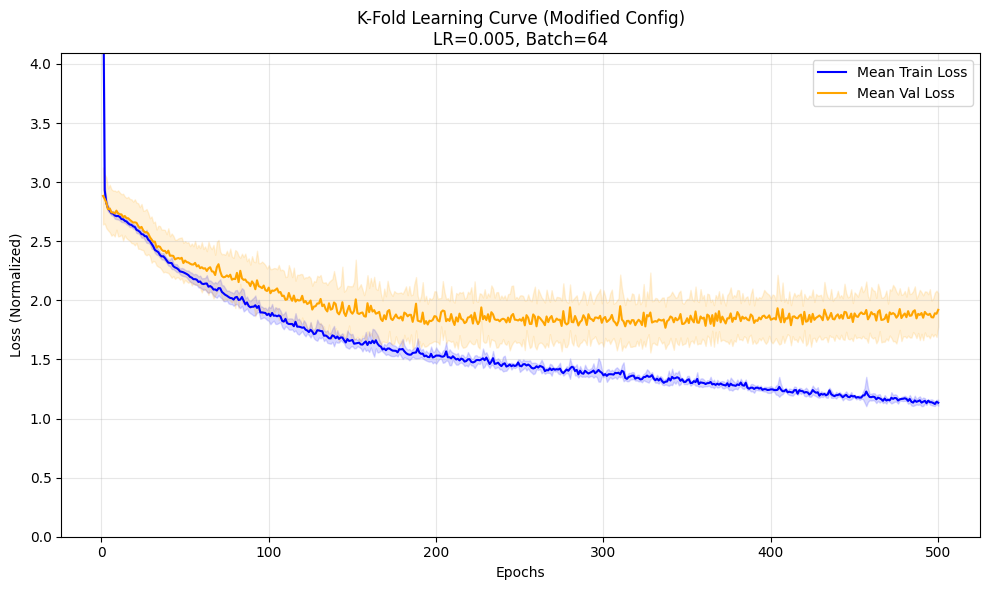

In [ ]:
import json
import copy
import numpy as np
import matplotlib.pyplot as plt
from training.model_factory import build_model_from_cfg
from training.kfold_cv import kfold_cross_validation
from training.trainer import Trainer
from nn.metrics import MEE
from nn.optim import SGDMomentum, Adam, SGD
from nn.losses import MSE

# 1. Carica la configurazione base
config_path = os.path.join(RESULTS_DIR, "best_config.json")
with open(config_path, 'r') as f:
    base_config = json.load(f)

# 2. Crea una copia modificabile
new_config = copy.deepcopy(base_config)

# ==============================================================================
# ZONA MODIFICHE: Scommenta e modifica i parametri che vuoi testare
# ==============================================================================

# --- A. Epoche di Test ---
# Se cambi LR o Architettura, potrebbe servire più o meno tempo.
# Di base usiamo quelle ottimali trovate prima, ma puoi mettere un numero fisso (es. 500)
TEST_EPOCHS = 500 
# TEST_EPOCHS = 500 

# --- B. Parametri Ottimizzatore ---
new_config['optim']['lr'] = 0.005
new_config['optim']['momentum'] = 0.8

# --- C. Architettura Modello ---
# new_config['model']['hidden_units'] = [64, 32] 
# new_config['model']['dropout'] = 0.1

# --- D. Batch Size ---
# new_config['training']['batch_size'] = 64

# --- E. Regolarizzazione ---
# new_config['regularizer']['l2'] = 1e-4

# ==============================================================================

print(f"--- TEST CONFIGURAZIONE MODIFICATA ---")
print(f"LR: {new_config['optim']['lr']} | Momentum: {new_config['optim']['momentum']}")
print(f"Hidden: {new_config['model']['hidden_units']} | Epochs: {TEST_EPOCHS}")

# 3. Costruzione del Modello
model_variant = build_model_from_cfg(
    new_config, 
    seed=42, 
    in_dim=in_dim, 
    out_dim=out_dim,
    task="regression" # Fondamentale
)

# Setup Componenti (Loss & Metriche)
loss_fn = MEE() if new_config.get('loss') == 'mee' else MSE()
model_variant.loss = loss_fn
model_variant.metrics = [MEE()]

# Setup Ottimizzatore (Switch intelligente tra SGD e Adam)
# Se vuoi usare Adam scommenta le righe sotto, altrimenti usa SGD dal config
model_variant.optimizer = SGDMomentum(
    lr=new_config['optim']['lr'], 
    momentum=new_config['optim']['momentum']
)
# model_variant.optimizer = Adam(lr=new_config['optim']['lr'])

# Reset callback (rimuovi early stopping per vedere tutta la curva)
model_variant.callbacks = []

# 4. Esecuzione K-Fold Cross Validation
cv_trainer = Trainer(model_variant, verbose=0) # Verbose 0 per pulizia

print(f"\nAvvio 5-Fold CV per {TEST_EPOCHS} epoche... (Attendere)")
train_stats, val_stats, histories, _ = kfold_cross_validation(
    X=X_dev, 
    y=y_dev, 
    model=model_variant,
    trainer=cv_trainer,
    k=5, 
    epochs=TEST_EPOCHS,
    batch_size=new_config['training']['batch_size'],
    normalize_data=True,
    normalize_target=True, # Loss normalizzata
    seed=42,
    verbose=0
)

# 5. Report Numerico
print("\n----------------------------------------------------")
print(f"RISULTATI (Loss Normalizzata - Media su 5 Fold)")
print("----------------------------------------------------")
print(f"Mean Val Loss: {val_stats['loss']['mean']:.5f} (+/- {val_stats['loss']['std']:.5f})")
if 'MeanEuclideanError' in val_stats:
    print(f"Mean Val MEE:  {val_stats['MeanEuclideanError']['mean']:.5f} (+/- {val_stats['MeanEuclideanError']['std']:.5f})")
print("----------------------------------------------------")

# 6. Plotting della Learning Curve (Aggregata)
# Estraiamo i log da ogni storia
train_losses = np.array([h.logs['loss'] for h in histories])      # (K, Epochs)
val_losses = np.array([h.logs['val_loss'] for h in histories])    # (K, Epochs)

# Calcoliamo media e deviazione standard epoca per epoca
mean_train = np.mean(train_losses, axis=0)
std_train = np.std(train_losses, axis=0)
mean_val = np.mean(val_losses, axis=0)
std_val = np.std(val_losses, axis=0)
epochs_range = range(1, len(mean_train) + 1)

plt.figure(figsize=(10, 6))

# Train
plt.plot(epochs_range, mean_train, label='Mean Train Loss', color='blue')
plt.fill_between(epochs_range, mean_train - std_train, mean_train + std_train, color='blue', alpha=0.15)

# Validation
plt.plot(epochs_range, mean_val, label='Mean Val Loss', color='orange')
plt.fill_between(epochs_range, mean_val - std_val, mean_val + std_val, color='orange', alpha=0.15)

plt.title(f'K-Fold Learning Curve (Modified Config)\nLR={new_config["optim"]["lr"]}, Batch={new_config["training"]["batch_size"]}')
plt.xlabel('Epochs')
plt.ylabel('Loss (Normalized)')
plt.legend()
plt.grid(True, alpha=0.3)

# Zoom y-axis per ignorare i picchi iniziali
plt.ylim(0, max(mean_val[10:]) * 1.5 if len(mean_val) > 10 else max(mean_val))

plt.tight_layout()
plt.show()

In [ ]:
from nn.metrics import MEE
from data_handler.data_loader import denormalize

# --- 1. CONFIGURAZIONE DEL RETRAINING ---
# Usiamo la 'new_config' che hai modificato nella cella precedente
# E usiamo le 'TEST_EPOCHS' che hai deciso (o le optimal_epochs)
print(f"Retraining Modified Model on full Development Set...")
print(f"Config: {new_config['model']['hidden_units']} | LR: {new_config['optim']['lr']}")
print(f"Epochs: {TEST_EPOCHS}")

# --- 2. COSTRUZIONE DEL MODELLO DEFINITIVO ---
final_variant_model = build_model_from_cfg(
    new_config, 
    seed=42, # Seed fisso per riproducibilità
    in_dim=in_dim, 
    out_dim=out_dim,
    task="regression"
)

# Setup Componenti (Esattamente come nella cella K-Fold)
loss_fn = MEE() if new_config.get('loss') == 'mee' else MSE()
final_variant_model.loss = loss_fn
final_variant_model.metrics = [MEE()]

# Setup Optimizer (SGD o Adam in base alla tua scelta nella cella precedente)
# Qui riprendiamo la logica: se nel config c'è momentum usiamo SGD, altrimenti controlla se volevi Adam
final_variant_model.optimizer = SGDMomentum(
    lr=new_config['optim']['lr'], 
    momentum=new_config['optim']['momentum']
)
# Se nella cella precedente usavi Adam, scommenta qui:
# final_variant_model.optimizer = Adam(lr=new_config['optim']['lr'])

# --- 3. ADDESTRAMENTO COMPLETO (Senza Validation) ---
variant_trainer = Trainer(final_variant_model, verbose=1)

variant_trainer.fit(
    X_train=X_dev_norm, # Tutto il dev set normalizzato
    y_train=y_dev_norm, # Tutto il target dev normalizzato
    X_val=None,         # Niente validation, vogliamo massimizzare l'apprendimento
    y_val=None,
    epochs=TEST_EPOCHS, 
    batch_size=new_config['training']['batch_size']
)

# --- 4. VALUTAZIONE SU BLIND TEST SET ---

# A. Caricamento e Normalizzazione Test Set (Se non fatto prima)
# Nota: Usiamo mean_x e std_x calcolati sul DEV set (fondamentale!)
X_test, y_test_real = load_cup(INT_TEST, training=True)
X_test_norm, _, _ = normalize(X_test, mean=mean_x, std=std_x)

# B. Predizione
y_pred_variant_norm = final_variant_model.predict(X_test_norm)

# C. Denormalizzazione (Riportiamo in scala reale)
y_pred_variant_real = denormalize(y_pred_variant_norm, mean_y, std_y)

# D. Calcolo MEE
mee_calc = MEE()
variant_mee = mee_calc(y_pred_variant_real, y_test_real)

print("\n================================================")
print(f"MODIFIED MODEL ASSESSMENT (Internal Test Set)")
print("================================================")
print(f"Configuration: LR={new_config['optim']['lr']}, Units={new_config['model']['hidden_units']}")
print(f"Final MEE (Real Scale): {variant_mee:.5f}")
print("================================================")

# (Opzionale) Confronto col modello base se esiste la variabile 'final_mee'
if 'final_mee' in locals():
    delta = final_mee - variant_mee
    if delta > 0:
        print(f"✅ MIGLIORAMENTO: L'errore è sceso di {delta:.5f} rispetto al modello base.")
    else:
        print(f"❌ PEGGIORAMENTO: L'errore è salito di {abs(delta):.5f} rispetto al modello base.")

Retraining Modified Model on full Development Set...
Config: [64, 32, 16] | LR: 0.005
Epochs: 500

      _____     ___                 _ _ _ 
      \_   \   / __\__ ___   ____ _| | (_)
       / /\/  / /  / _` \ \ / / _` | | | |
    /\/ /_   / /__| (_| |\ V / (_| | | | |
    \____/   \____/\__,_| \_/ \__,_|_|_|_|
    
Epoch 1/500 [>.............................] loss: 4.6444 MEE: 1.9869Epoch 2/500 [>.............................] loss: 2.9613 MEE: 1.5877Epoch 3/500 [>.............................] loss: 2.7991 MEE: 1.5571Epoch 4/500 [>.............................] loss: 2.7712 MEE: 1.5323Epoch 5/500 [>.............................] loss: 2.7387 MEE: 1.5287Epoch 6/500 [>.............................] loss: 2.7340 MEE: 1.5263Epoch 7/500 [>.............................] loss: 2.7230 MEE: 1.5225Epoch 8/500 [>.............................] loss: 2.7352 MEE: 1.5218Epoch 9/500 [>.............................] loss: 2.7047 MEE: 1.5166Epoch 10/500 [>.............................] loss: 2.7020 M

In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Aggiunge la root al path
sys.path.append(os.getcwd())

from experiments.CUP import common
from training.trainer import Trainer
from training.gridsearch import _hash_config # Per trovare l'ID della config
from data_handler.data_loader import normalize
from nn.metrics import MEE

# --- CONFIGURAZIONE PATH ---
RESULTS_DIR = 'experiments/CUP/results/cup_exp_1' # La tua cartella risultati
BEST_CONFIG_PATH = os.path.join(RESULTS_DIR, 'best_config.json')
FINE_SUMMARY_PATH = os.path.join(RESULTS_DIR, 'fine_summary.csv')

INT_TRAIN = 'data/CUP/internal_train_80.csv'
INT_TEST  = 'data/CUP/internal_test_20.csv'

print("=== 1. RECUPERO CONFIGURAZIONE E BEST EPOCH ===")

# A. Carica la Best Config
if not os.path.exists(BEST_CONFIG_PATH):
    raise FileNotFoundError(f"Non trovo il file {BEST_CONFIG_PATH}. Hai lanciato la grid search?")

with open(BEST_CONFIG_PATH, 'r') as f:
    best_config = json.load(f)

# B. Recupera la Best Epoch media dal summary della fine search
# Calcoliamo l'ID della config per trovarla nel CSV
config_id = _hash_config(best_config)
print(f"Best Config ID: {config_id}")

df_summary = pd.read_csv(FINE_SUMMARY_PATH)
# Cerca la riga corrispondente
row = df_summary[df_summary['config_id'] == config_id]

if row.empty:
    print("WARNING: Config ID non trovato nel summary. Uso le epoche di default del config.")
    best_epoch = best_config['training']['epochs']
else:
    # Prende la media delle migliori epoche (best_epoch_mean)
    mean_epoch = row['best_epoch_mean'].values[0]
    best_epoch = int(round(mean_epoch))
    print(f"Best Epoch (Mean over Folds): {mean_epoch:.2f} -> Usiamo: {best_epoch}")

print(f"\nConfigurazione scelta: {best_config['model']}")
print(f"Hyperparams: LR={best_config['optim']['lr']}, Momentum={best_config['optim']['momentum']}")

# === 2. PREPARAZIONE DATI (DEV + TEST) ===
print("\n=== 2. DATA LOADING & NORMALIZATION ===")

# Carichiamo i dati GREZZI
X_dev_raw, y_dev = common.load_cup(INT_TRAIN, training=True)
X_test_raw, y_test_raw = common.load_cup(INT_TEST, training=True)

# Logica di Normalizzazione (Fit su Dev -> Transform su Test)
do_normalize = best_config.get('data', {}).get('normalize', False)

if do_normalize:
    print("-> Normalizzazione Attiva (Fit on Dev, Transform on Test)")
    X_dev, mean_x, std_x = normalize(X_dev_raw)
    X_test, _, _ = normalize(X_test_raw, mean=mean_x, std=std_x)
else:
    print("-> Nessuna normalizzazione.")
    X_dev, X_test = X_dev_raw, X_test_raw

# ==========================================
# 3. RETRAINING & ASSESSMENT FINALE (CORRETTO)
# ==========================================
print("\n=== Retraining Best Model on Full Development Set ===")

# 1. Recupera la Best Config (Ce l'hai già dalla Sezione 1, non serve ricaricarla se è in memoria)
# best_config = best_result['best_config'] # Usa quella già caricata e processata

# 2. Carica i dati GREZZI
X_dev_raw, y_dev = common.load_cup(INT_TRAIN, training=True)
X_test_raw, y_test_raw = common.load_cup(INT_TEST, training=True)

# 3. Normalizzazione Manuale
do_normalize = best_config.get('data', {}).get('normalize', False)

if do_normalize:
    print("-> Normalizzazione Attiva (Fit on Dev, Transform on Test)")
    X_dev, mean_x, std_x = normalize(X_dev_raw)
    X_test, _, _ = normalize(X_test_raw, mean=mean_x, std=std_x)
else:
    print("-> Nessuna normalizzazione.")
    X_dev, X_test = X_dev_raw, X_test_raw

# 4. Modifica Config per Retraining Fisso
# IMPORTANTE: Usiamo la best_epoch calcolata nella Sezione 1!
print(f"-> Impostazione epoche fisse: {best_epoch} (media dai fold)")
final_epochs = best_epoch 

# IMPORTANTE: Disabilitiamo Early Stopping per garantire che arrivi in fondo
# Se early_stopping è attivo, potrebbe fermarsi prima, invalidando la statistica della media.
if 'callbacks' in best_config and 'early_stopping' in best_config['callbacks']:
    print("-> Disabilitazione Early Stopping per il retraining.")
    best_config['callbacks']['early_stopping'] = False

# 5. Costruzione Modello
final_model = common.build_model(best_config, seed=42)
trainer = Trainer(final_model, verbose=1)

# 6. Training
history = trainer.fit(
    X_train=X_dev, 
    y_train=y_dev,
    X_val=X_test, 
    y_val=y_test_raw, 
    epochs=final_epochs, # <--- USA LA VARIABILE CALCOLATA
    batch_size=best_config['training']['batch_size'],
    include_reg_in_val=False
)

# 7. Estrazione Storico
history_data = history.to_dict()
train_loss = history_data['loss']
if 'val_loss' in history_data:
    val_loss = history_data['val_loss']
else:
    val_loss = []

# 8. Assessment Finale
y_pred = final_model.predict(X_test)
mee_metric = MEE()
final_mee = mee_metric.compute(y_pred, y_test_raw)

# print(f"\n" + "="*50)
# print(f"RISULTATO FINALE (Internal Test 20%)")
# print(f"MEE: {final_mee:.5f}")
# print("="*50)

=== 1. RECUPERO CONFIGURAZIONE E BEST EPOCH ===
Best Config ID: 366925f87d0a
Best Epoch (Mean over Folds): 220.60 -> Usiamo: 221

Configurazione scelta: {'activation': 'relu', 'dropout': 0.0, 'hidden_units': [8, 6], 'output_activation': 'linear'}
Hyperparams: LR=0.001, Momentum=0.7

=== 2. DATA LOADING & NORMALIZATION ===
-> Normalizzazione Attiva (Fit on Dev, Transform on Test)

=== Retraining Best Model on Full Development Set ===
-> Normalizzazione Attiva (Fit on Dev, Transform on Test)
-> Impostazione epoche fisse: 221 (media dai fold)
-> Disabilitazione Early Stopping per il retraining.

      _____     ___                 _ _ _ 
      \_   \   / __\__ ___   ____ _| | (_)
       / /\/  / /  / _` \ \ / / _` | | | |
    /\/ /_   / /__| (_| |\ V / (_| | | | |
    \____/   \____/\__,_| \_/ \__,_|_|_|_|
    
Epoch 1/221 [>.............................] loss: 1466.6204 MSE: 1465.8296 val_loss: 1498.4238 val_MSE: 1498.4238Epoch 2/221 [>.............................] loss: 1070.4987 MSE: 


=== Generazione K-Fold Learning Curve (Early Stopping Attivo) ===
Max Epochs impostate: 800
Early Stopping: False
Esecuzione 5-Fold CV...

Starting 5-Fold Cross Validation
Elaborazione curve di lunghezza diversa...


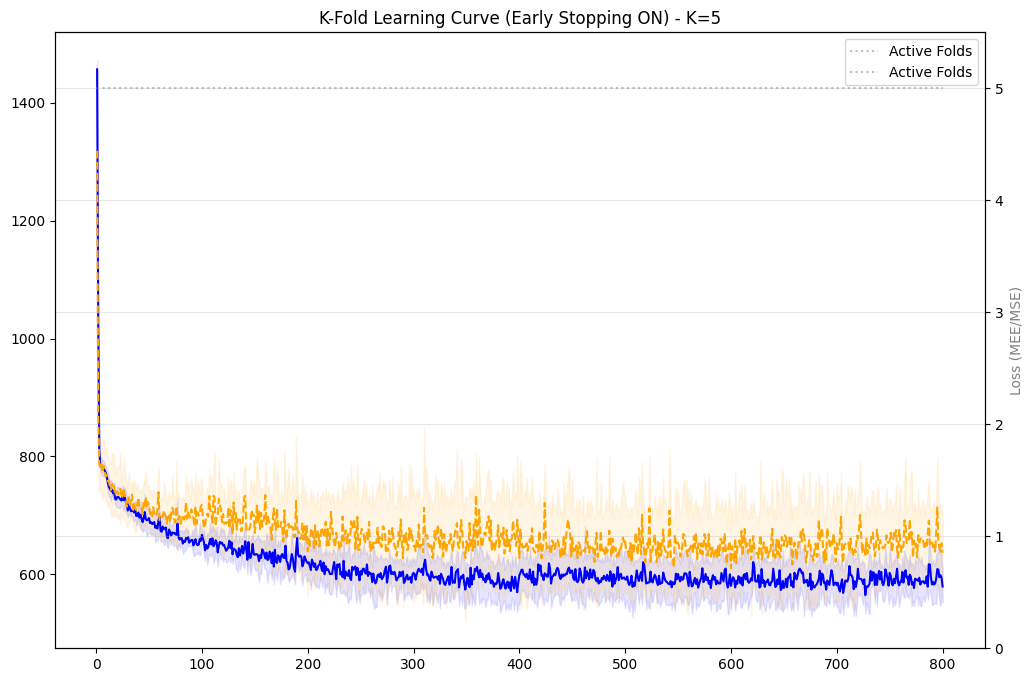

Durata media: 800 epoche
Loss Val Finale (Ultimo punto valido): 636.14210


In [ ]:
# ==========================================
# 4. LEARNING CURVE CON K-FOLD (Early Stopping ATTIVO)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import warnings  # <--- CORREZIONE: Importiamo il modulo standard
from training.kfold_cv import kfold_cross_validation
from training.trainer import Trainer

print("\n=== Generazione K-Fold Learning Curve (Early Stopping Attivo) ===")

# 1. Configurazione
run_config = best_config.copy()
# (Opzionale) Aumenta le epoche se vuoi stressare l'Early Stopping
# run_config['training']['epochs'] = 1000 

print(f"Max Epochs impostate: {run_config['training']['epochs']}")
if 'callbacks' in run_config and 'early_stopping' in run_config['callbacks']:
    print(f"Early Stopping: {run_config['callbacks']['early_stopping']}")
else:
    print("Early Stopping non trovato nel config.")

k_folds = 5 

# 2. Dati
X_dev_raw, y_dev = common.load_cup(INT_TRAIN, training=True)
do_normalize = run_config.get('data', {}).get('normalize', False)

# 3. Esecuzione K-Fold
model_dummy = common.build_model(run_config, seed=42)
trainer_dummy = Trainer(model_dummy, verbose=0)

print(f"Esecuzione {k_folds}-Fold CV...")
_, _, histories, _ = kfold_cross_validation(
    X=X_dev_raw,
    y=y_dev,
    model=model_dummy,
    trainer=trainer_dummy,
    k=k_folds,
    epochs=run_config['training']['epochs'],
    batch_size=run_config['training']['batch_size'],
    shuffle=True,
    seed=42,
    verbose=0,
    normalize_data=do_normalize,
    include_reg_in_val=False 
)

# 4. GESTIONE LUNGHEZZE VARIABILI (Padding)
print("Elaborazione curve di lunghezza diversa...")

try:
    train_losses_list = [h.to_dict()['loss'] for h in histories]
    val_losses_list = [h.to_dict()['val_loss'] for h in histories]
except AttributeError:
    train_losses_list = [h.history['loss'] for h in histories]
    val_losses_list = [h.history['val_loss'] for h in histories]

# Troviamo la durata massima
max_len = max(len(h) for h in train_losses_list)

# Matrici con NaN
train_matrix = np.full((k_folds, max_len), np.nan)
val_matrix = np.full((k_folds, max_len), np.nan)

for i in range(k_folds):
    n_epochs_fold = len(train_losses_list[i])
    train_matrix[i, :n_epochs_fold] = train_losses_list[i]
    val_matrix[i, :n_epochs_fold] = val_losses_list[i]

# 5. Calcolo Statistiche (CORRETTO PER NUMPY NUOVO)
# Usiamo il modulo 'warnings' standard invece di np.warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning) # Ignora "Mean of empty slice"
    mean_train = np.nanmean(train_matrix, axis=0)
    std_train = np.nanstd(train_matrix, axis=0)
    mean_val = np.nanmean(val_matrix, axis=0)
    std_val = np.nanstd(val_matrix, axis=0)

# 6. Plotting
# Filtriamo i NaN finali (dove tutti i fold sono finiti)
valid_indices = ~np.isnan(mean_train)
mean_train = mean_train[valid_indices]
std_train = std_train[valid_indices]
mean_val = mean_val[valid_indices]
std_val = std_val[valid_indices]

x_axis = range(1, len(mean_train) + 1)

plt.figure(figsize=(12, 8))

# Training
plt.plot(x_axis, mean_train, label='Train Loss (Active Folds)', color='blue')
plt.fill_between(x_axis, mean_train - std_train, mean_train + std_train, color='blue', alpha=0.1)

# Validation
plt.plot(x_axis, mean_val, label='Val Loss (Active Folds)', color='orange', linestyle='--')
plt.fill_between(x_axis, mean_val - std_val, mean_val + std_val, color='orange', alpha=0.1)

# Conta fold attivi
active_folds = np.sum(~np.isnan(val_matrix), axis=0)[:len(mean_val)]
ax2 = plt.gca().twinx()
ax2.plot(x_axis, active_folds, color='gray', linestyle=':', alpha=0.5, label='Active Folds')
ax2.set_ylabel('Active Folds', color='gray')
ax2.set_ylim(0, k_folds + 0.5)

plt.title(f'K-Fold Learning Curve (Early Stopping ON) - K={k_folds}')
plt.xlabel('Epochs')
plt.ylabel('Loss (MEE/MSE)')

lines, labels = plt.gca().get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.legend(lines + lines2, labels + labels2, loc='upper right')

plt.grid(True, alpha=0.3)
plt.show()

print(f"Durata media: {len(mean_train)} epoche")
print(f"Loss Val Finale (Ultimo punto valido): {mean_val[-1]:.5f}")


=== Generazione K-Fold Learning Curve (MEE) ===
Esecuzione 5-Fold CV...

Starting 5-Fold Cross Validation
Elaborazione dati...
Chiavi disponibili nello storico: ['loss', 'MSE', 'val_loss', 'val_MSE']
-> ATTENZIONE: Metrica MEE non trovata nello storico. Plotterò la LOSS (MSE).


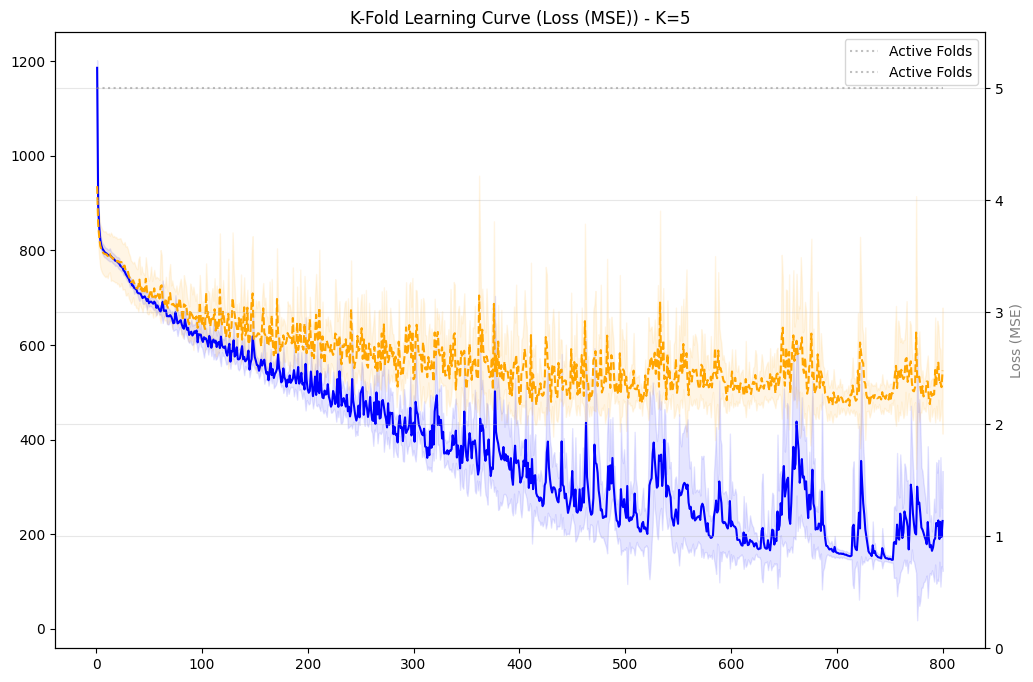

Valore Finale (loss): 545.75629 ± 133.36305


In [ ]:
# ==========================================
# 4. LEARNING CURVE CON K-FOLD (METRICA MEE)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import warnings
from training.kfold_cv import kfold_cross_validation
from training.trainer import Trainer

print("\n=== Generazione K-Fold Learning Curve (MEE) ===")

# 1. Configurazione
run_config = best_config.copy()
# (Opzionale) Aumenta le epoche
# run_config['training']['epochs'] = 1000 

k_folds = 5 

# 2. Dati
X_dev_raw, y_dev = common.load_cup(INT_TRAIN, training=True)
do_normalize = run_config.get('data', {}).get('normalize', False)

# 3. Esecuzione K-Fold
model_dummy = common.build_model(run_config, seed=42)
trainer_dummy = Trainer(model_dummy, verbose=0)

print(f"Esecuzione {k_folds}-Fold CV...")
_, _, histories, _ = kfold_cross_validation(
    X=X_dev_raw,
    y=y_dev,
    model=model_dummy,
    trainer=trainer_dummy,
    k=k_folds,
    epochs=run_config['training']['epochs'],
    batch_size=run_config['training']['batch_size'],
    shuffle=True,
    seed=42,
    verbose=0,
    normalize_data=do_normalize,
    include_reg_in_val=False 
)

# 4. GESTIONE ESTRAMI E SCELTA METRICA
print("Elaborazione dati...")

# Convertiamo tutti gli oggetti history in dizionari
history_dicts = []
for h in histories:
    try:
        history_dicts.append(h.to_dict())
    except AttributeError:
        history_dicts.append(h.history)

# --- LOGICA DI RILEVAMENTO METRICA ---
# Controlliamo le chiavi disponibili nel primo fold
available_keys = history_dicts[0].keys()
print(f"Chiavi disponibili nello storico: {list(available_keys)}")

# Cerchiamo varianti comuni del nome MEE
possible_mee_keys = ['mee', 'MEE', 'mean_euclidean_error']
target_key = None
val_target_key = None

for key in possible_mee_keys:
    if key in available_keys:
        target_key = key
        # Cerchiamo la corrispettiva validazione (es. 'val_mee')
        if f"val_{key}" in available_keys:
            val_target_key = f"val_{key}"
        elif "val_MEE" in available_keys: # Caso specifico se key='MEE'
            val_target_key = "val_MEE"
        break

if target_key:
    print(f"-> Trovata metrica MEE! Plotterò: '{target_key}' e '{val_target_key}'")
    y_label_text = "MEE (Mean Euclidean Error)"
else:
    print("-> ATTENZIONE: Metrica MEE non trovata nello storico. Plotterò la LOSS (MSE).")
    target_key = 'loss'
    val_target_key = 'val_loss' if 'val_loss' in available_keys else None
    y_label_text = "Loss (MSE)"

# 5. ESTRAZIONE E PADDING (NaN)
train_values_list = [h[target_key] for h in history_dicts]
val_values_list = [h[val_target_key] for h in history_dicts] if val_target_key else []

max_len = max(len(h) for h in train_values_list)
train_matrix = np.full((k_folds, max_len), np.nan)
val_matrix = np.full((k_folds, max_len), np.nan)

for i in range(k_folds):
    n = len(train_values_list[i])
    train_matrix[i, :n] = train_values_list[i]
    if val_values_list:
        val_matrix[i, :n] = val_values_list[i]

# 6. CALCOLO STATISTICHE
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    mean_train = np.nanmean(train_matrix, axis=0)
    std_train = np.nanstd(train_matrix, axis=0)
    
    if val_values_list:
        mean_val = np.nanmean(val_matrix, axis=0)
        std_val = np.nanstd(val_matrix, axis=0)
    else:
        mean_val, std_val = None, None

# Pulizia NaN finali
valid_indices = ~np.isnan(mean_train)
mean_train = mean_train[valid_indices]
std_train = std_train[valid_indices]
if mean_val is not None:
    mean_val = mean_val[valid_indices]
    std_val = std_val[valid_indices]

x_axis = range(1, len(mean_train) + 1)

# 7. PLOTTING
plt.figure(figsize=(12, 8))

# Train
plt.plot(x_axis, mean_train, label=f'Train {target_key} (Active Folds)', color='blue')
plt.fill_between(x_axis, mean_train - std_train, mean_train + std_train, color='blue', alpha=0.1)

# Val
if mean_val is not None:
    plt.plot(x_axis, mean_val, label=f'Val {target_key} (Active Folds)', color='orange', linestyle='--')
    plt.fill_between(x_axis, mean_val - std_val, mean_val + std_val, color='orange', alpha=0.1)

# Active Folds (asse destro)
active_folds = np.sum(~np.isnan(train_matrix), axis=0)[:len(mean_train)]
ax2 = plt.gca().twinx()
ax2.plot(x_axis, active_folds, color='gray', linestyle=':', alpha=0.5, label='Active Folds')
ax2.set_ylabel('Active Folds', color='gray')
ax2.set_ylim(0, k_folds + 0.5)

plt.title(f'K-Fold Learning Curve ({y_label_text}) - K={k_folds}')
plt.xlabel('Epochs')
plt.ylabel(y_label_text)

lines, labels = plt.gca().get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.legend(lines + lines2, labels + labels2, loc='upper right')

plt.grid(True, alpha=0.3)
plt.show()

if mean_val is not None:
    print(f"Valore Finale ({target_key}): {mean_val[-1]:.5f} ± {std_val[-1]:.5f}")